# Step 0: Import files

In [1]:
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
import shap 

import graphviz
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss


df_team_stats = pd.read_csv("TeamStatistics.csv")
df_team_stats_ext = pd.read_csv("TeamStatisticsExtended.csv")

/opt/homebrew/Cellar/micromamba/2.5.0/envs/ronan_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Step 1: Create Dataframe (Dataframe is put into df_nba_full_ext)

#### If you're curious about the data

In [2]:
df_team_stats
print("\nRow count:", len(df_team_stats)/2)
print("Columns:", list(df_team_stats.columns))

df_team_stats_ext
print("\nRow count:", len(df_team_stats_ext)/2)
print("Columns:", list(df_team_stats_ext.columns))



Row count: 73280.0
Columns: ['gameId', 'gameDateTimeEst', 'teamCity', 'teamName', 'teamId', 'opponentTeamCity', 'opponentTeamName', 'opponentTeamId', 'home', 'win', 'teamScore', 'opponentScore', 'assists', 'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade', 'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade', 'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade', 'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive', 'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints', 'numMinutes', 'q1Points', 'q2Points', 'q3Points', 'q4Points', 'benchPoints', 'biggestLead', 'biggestScoringRun', 'leadChanges', 'pointsFastBreak', 'pointsFromTurnovers', 'pointsInThePaint', 'pointsSecondChance', 'timesTied', 'timeoutsRemaining', 'seasonWins', 'seasonLosses', 'coachId', 'gameType', 'gameLabel', 'gameSubLabel', 'seriesGameNumber', 'seed', 'reboundsTeam', 'turnoversTeam', 'ot1Points', 'ot2Points', 'otAllPoints', 'gameDate']

Row count: 39862.0

## Clean Missing Data

### Identify Missing Games + Filter them out

In [3]:
# Get the set of gameIds from df_team_stats_ext
game_ids_main = set(df_team_stats_ext['gameId'])

# Collect missing rows while iterating
missing_dates = []

for _, row in df_team_stats.iterrows():
    game_id = row['gameId']
    # Check if gameId is missing in df_team_stats_ext 
    if game_id not in game_ids_main :
        print("GameId:", game_id,
              "| Date:", row['gameDateTimeEst'],
              "| Team:", row['teamName'],
              "| Opponent:", row['opponentTeamName'])
        # Store the date
        missing_dates.append(row['gameDateTimeEst'])

# Convert to DataFrame for plotting
missing_df = pd.DataFrame({'gameDateTimeEst': missing_dates})
missing_df['year'] = pd.to_datetime(missing_df['gameDateTimeEst']).dt.year

GameId: 62400001 | Date: 2024-12-17 20:30:00 | Team: Bucks | Opponent: Thunder
GameId: 62400001 | Date: 2024-12-17 20:30:00 | Team: Thunder | Opponent: Bucks
GameId: 62300001 | Date: 2023-12-09 20:30:00 | Team: Lakers | Opponent: Pacers
GameId: 62300001 | Date: 2023-12-09 20:30:00 | Team: Pacers | Opponent: Lakers
GameId: 10600116 | Date: 2006-10-27 20:00:00 | Team: Bucks | Opponent: Timberwolves
GameId: 10600116 | Date: 2006-10-27 20:00:00 | Team: Timberwolves | Opponent: Bucks
GameId: 10600114 | Date: 2006-10-26 22:00:00 | Team: Nuggets | Opponent: Lakers
GameId: 10600114 | Date: 2006-10-26 22:00:00 | Team: Lakers | Opponent: Nuggets
GameId: 10600094 | Date: 2006-10-24 19:00:00 | Team: Pacers | Opponent: Bobcats
GameId: 10600094 | Date: 2006-10-24 19:00:00 | Team: Bobcats | Opponent: Pacers
GameId: 10600089 | Date: 2006-10-22 21:30:00 | Team: Lakers | Opponent: Suns
GameId: 10600089 | Date: 2006-10-22 21:30:00 | Team: Suns | Opponent: Lakers
GameId: 10600087 | Date: 2006-10-22 20:00:

Plot

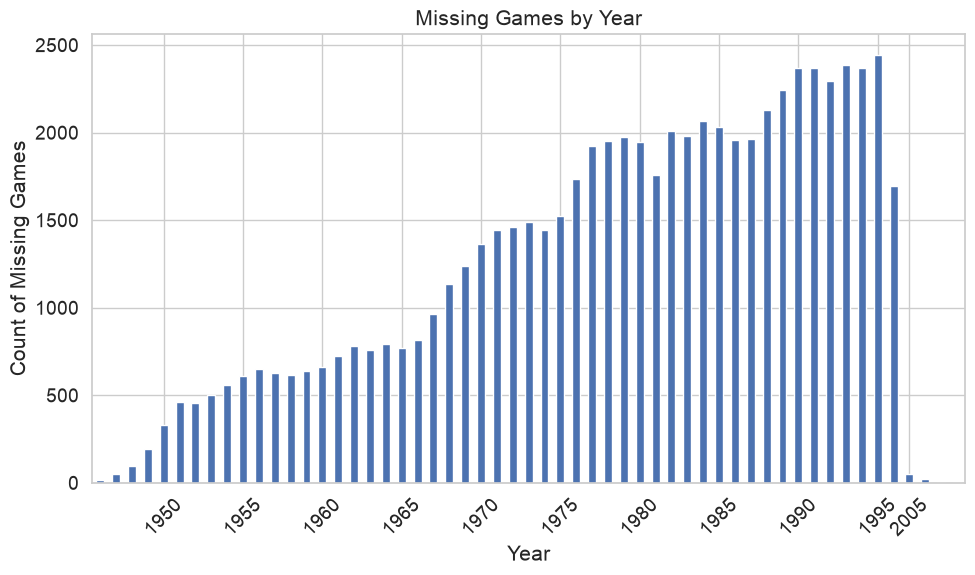

In [4]:
# Plot missing data by year
counts = missing_df['year'].value_counts().sort_index()
ax = counts.plot(kind='bar', figsize=(10,6))

# Extract the sorted years (these are the categorical x labels)
years = counts.index.tolist()

# Choose only every 5th year label
tick_positions = [i for i, y in enumerate(years) if y % 5 == 0]
tick_labels = [y for y in years if y % 5 == 0]

# Apply them
plt.xticks(tick_positions, tick_labels, rotation=45)

plt.title("Missing Games by Year")
plt.xlabel("Year")
plt.ylabel("Count of Missing Games")
plt.tight_layout()
plt.show()


Check if there is missing data after 1996

In [5]:
game_ids_main = set(df_team_stats_ext['gameId'])

total_games = len(df_team_stats) / 2
missing_rows = []

for _, row in df_team_stats.iterrows():
    game_id = row['gameId']
    game_year = pd.to_datetime(row['gameDateTimeEst']).year
    
    # Check if gameId is missing in df_team_stats_ext AND after 1996
    if game_id not in game_ids_main and game_year > 1996:
        print("GameId:", game_id,
              "| Date:", row['gameDateTimeEst'],
              "| Team:", row['teamName'],
              "| Opponent:", row['opponentTeamName'])
    
        missing_rows.append({
            "gameId": game_id,
            "gameDateTimeEst": row['gameDateTimeEst'],
            "teamName": row['teamName'],
            "opponentTeamName": row['opponentTeamName'],
            "year": game_year
        })
        
missing_df = pd.DataFrame(missing_rows)

GameId: 62400001 | Date: 2024-12-17 20:30:00 | Team: Bucks | Opponent: Thunder
GameId: 62400001 | Date: 2024-12-17 20:30:00 | Team: Thunder | Opponent: Bucks
GameId: 62300001 | Date: 2023-12-09 20:30:00 | Team: Lakers | Opponent: Pacers
GameId: 62300001 | Date: 2023-12-09 20:30:00 | Team: Pacers | Opponent: Lakers
GameId: 10600116 | Date: 2006-10-27 20:00:00 | Team: Bucks | Opponent: Timberwolves
GameId: 10600116 | Date: 2006-10-27 20:00:00 | Team: Timberwolves | Opponent: Bucks
GameId: 10600114 | Date: 2006-10-26 22:00:00 | Team: Nuggets | Opponent: Lakers
GameId: 10600114 | Date: 2006-10-26 22:00:00 | Team: Lakers | Opponent: Nuggets
GameId: 10600094 | Date: 2006-10-24 19:00:00 | Team: Pacers | Opponent: Bobcats
GameId: 10600094 | Date: 2006-10-24 19:00:00 | Team: Bobcats | Opponent: Pacers
GameId: 10600089 | Date: 2006-10-22 21:30:00 | Team: Lakers | Opponent: Suns
GameId: 10600089 | Date: 2006-10-22 21:30:00 | Team: Suns | Opponent: Lakers
GameId: 10600087 | Date: 2006-10-22 20:00:

Plot


Missing games by year:
year
2005    50
2006    24
2023     2
2024     2
Name: count, dtype: int64


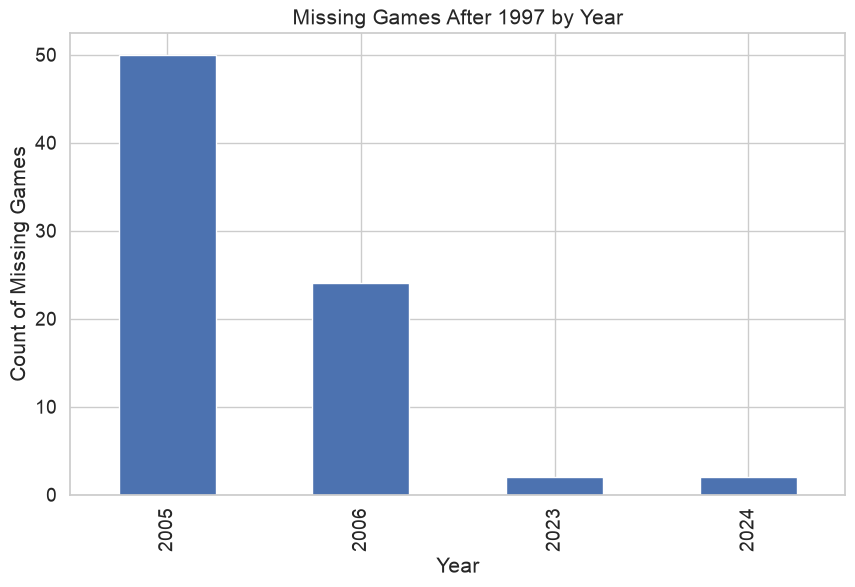

In [6]:
# Breakdown by year
year_counts = missing_df['year'].value_counts().sort_index()
print("\nMissing games by year:")
print(year_counts)

# Plot
year_counts.plot(kind='bar', figsize=(10,6))
plt.title("Missing Games After 1997 by Year")
plt.xlabel("Year")
plt.ylabel("Count of Missing Games")
plt.show()

Summary stats

In [7]:
bad_game_ids = missing_df["gameId"].unique()
df_team_stats_clean = df_team_stats[~df_team_stats["gameId"].isin(bad_game_ids)].copy()

print("Original size:", len(df_team_stats))
print("Cleaned size:", len(df_team_stats_clean))
print("Deleted rows:", len(df_team_stats) - len(df_team_stats_clean))


Original size: 146560
Cleaned size: 146482
Deleted rows: 78


### Clean The Bad/ Missing Rows

In [8]:
mismatches = []

for i in range(0, len(df_team_stats), 2):
    row1 = df_team_stats.iloc[i]
    row2 = df_team_stats.iloc[i+1]

    cond1 = (row1["teamName"] == row2["opponentTeamName"]) and (row1["teamId"] == row2["opponentTeamId"])
    cond2 = (row2["teamName"] == row1["opponentTeamName"]) and (row2["teamId"] == row1["opponentTeamId"])

    if not (cond1 and cond2):
        mismatches.append(row1["gameId"])

# Show both rows for each mismatched gameId
for gid in mismatches:
    bad_rows = df_team_stats[df_team_stats["gameId"] == gid]
    print("\n=== Mismatch for GameId:", gid, "===")
    print(bad_rows)

# Identify the bad row: same gameId but missing team/opponent info
bad_rows = df_team_stats[
    (df_team_stats["gameId"] == 22500652) &
    (df_team_stats["teamName"].isna()) &
    (df_team_stats["opponentTeamName"].isna())
]

print("Bad rows to delete:")
print(bad_rows[["gameId","gameDateTimeEst","teamName","opponentTeamName"]])

# Drop those rows
df_team_stats_clean = df_team_stats.drop(bad_rows.index).copy()

print("Original size:", len(df_team_stats))
print("Cleaned size:", len(df_team_stats_clean))


=== Mismatch for GameId: 22500652 ===
        gameId      gameDateTimeEst   teamCity   teamName      teamId  \
378   22500652  2026-03-31 20:00:00     Dallas  Mavericks  1610612742   
379   22500652  2026-03-31 20:00:00  Milwaukee      Bucks  1610612749   
1302  22500652  2026-01-25 14:00:00        NaN        NaN           0   

     opponentTeamCity opponentTeamName  opponentTeamId  home  win  ...  \
378         Milwaukee            Bucks      1610612749     0  0.0  ...   
379            Dallas        Mavericks      1610612742     1  1.0  ...   
1302              NaN              NaN               0     1  NaN  ...   

      gameLabel  gameSubLabel  seriesGameNumber  seed  reboundsTeam  \
378         NaN           NaN               NaN   NaN           7.0   
379         NaN           NaN               NaN   NaN          10.0   
1302        NaN           NaN               NaN   NaN           NaN   

      turnoversTeam  ot1Points  ot2Points  otAllPoints             gameDate  
378     

Find odd game becuase we have an odd number of rows

In [9]:
counts = df_team_stats_clean["gameId"].value_counts()

# Find gameIds that don't have exactly 2 rows
odd_games = counts[counts != 2]

print("Odd games (not exactly 2 rows):")
print(odd_games)

# Inspect odd games (those with != 2 rows)
counts = df_team_stats_clean["gameId"].value_counts()
odd_games = counts[counts != 2]

# Show all rows for each odd gameId
for gid in odd_games.index:
    bad_rows = df_team_stats_clean[df_team_stats_clean["gameId"] == gid]
    print("\n=== Odd GameId:", gid, "===")
    print(bad_rows[["gameId","gameDateTimeEst","teamName","teamId","opponentTeamName","opponentTeamId"]])

Odd games (not exactly 2 rows):
gameId
22500651    3
Name: count, dtype: int64

=== Odd GameId: 22500651 ===
        gameId      gameDateTimeEst   teamName      teamId opponentTeamName  \
572   22500651  2026-03-18 20:30:00    Nuggets  1610612743        Grizzlies   
573   22500651  2026-03-18 20:30:00  Grizzlies  1610612763          Nuggets   
1303  22500651  2026-01-25 10:30:00        NaN           0              NaN   

      opponentTeamId  
572       1610612763  
573       1610612743  
1303               0  


Identify and drop

In [10]:
# Identify the bad row: same gameId but missing team/opponent info
bad_rows = df_team_stats_clean[
    (df_team_stats_clean["gameId"] == 22500651) &
    (df_team_stats_clean["teamName"].isna()) &
    (df_team_stats_clean["opponentTeamName"].isna())
]

print("Bad rows to delete:")
print(bad_rows[["gameId","gameDateTimeEst","teamName","opponentTeamName"]])

# Drop those rows
df_team_stats_clean = df_team_stats_clean.drop(bad_rows.index).copy()

Bad rows to delete:
        gameId      gameDateTimeEst teamName opponentTeamName
1303  22500651  2026-01-25 10:30:00      NaN              NaN


Check process

In [11]:
# Print to see
print("Original size:", len(df_team_stats))
print("Cleaned size:", len(df_team_stats_clean))

# Check that every gameId has exactly 2 rows
counts = df_team_stats_clean["gameId"].value_counts()
odd_games = counts[counts != 2]

if odd_games.empty:
    print("All games have exactly 2 rows.")
else:
    print("Odd games detected:")
    print(odd_games)

# Sanity check symmetry for each pair
mismatches = []
for i in range(0, len(df_team_stats_clean), 2):
    row1 = df_team_stats_clean.iloc[i]
    row2 = df_team_stats_clean.iloc[i+1]

    cond1 = (row1["teamName"] == row2["opponentTeamName"]) and (row1["teamId"] == row2["opponentTeamId"])
    cond2 = (row2["teamName"] == row1["opponentTeamName"]) and (row2["teamId"] == row1["opponentTeamId"])

    if not (cond1 and cond2):
        mismatches.append(row1["gameId"])

if not mismatches:
    print("All pairs match correctly.")
else:
    print("Mismatched gameIds:", mismatches)
    for gid in mismatches:
        bad_rows = df_team_stats_clean[df_team_stats_clean["gameId"] == gid]
        print("\n=== Mismatch for GameId:", gid, "===")
        print(bad_rows[["gameId","gameDateTimeEst","teamName","teamId","opponentTeamName","opponentTeamId"]])


Original size: 146560
Cleaned size: 146558
All games have exactly 2 rows.
All pairs match correctly.


### Merging to Create Dataset

#### Method 1: Combining the winning and losing teams regular and extended stats into one long dataframe (Commented out but kept incase it was circled back to in the future)

Create an empty DataFrame with the desired columns

In [12]:
# columns=[
#     # overall game logistics
#     "game_Id", "game_DateTimeEst", "game_Date",
#     "game_LeadChanges", "game_TimesTied",
#     "game_Type", "game_Label", "game_SubLabel", "game_SeriesGameNumber", 

#     # Win team data columns
#     "win_Team", "win_TeamId", 
#     "win_teamScore", "win_Ast", "win_Blk", "win_Stl", "win_FGM", "win_FGA", "win_FG%", "win_3PM",
#     "win_3PA", "win_3P%", "win_FTM", "win_FTA", "win_FT%", "win_DReb", "win_OReb", "win_TReb",
#     "win_PF", "win_TO", "win_+/-" ,"win_numMinutes", "win_Q1Points" , "win_Q2Points",
#     "win_Q3Points", "win_Q4Points", "win_BenchPoints", "win_BiggestLead", "win_BiggestScoringRun",
#     "win_FastBreakPoints", "win_PointsInPaint", "win_SecondChancePoints", "win_TimeOutsRemaiing",
#     "win_SeasonWins", "win_SeasonLosses", "win_CoachId", "win_Seed", "win_TeamReb", "win_TeamTO",
#     "win_OT1Points", "win_OT2Points", "win_OTTotalPoints", 

#     # Win team extended metrics
#     "win_PFDrawn", "win_EstOffRTG", "win_OffRTG", "win_EstDefRTG", "win_DefRTG", "win_EstNetRTG",
#     "win_NetRTG", "win_AST%", "win_A/TO", "win_AstRatio", "win_OReb%", "win_DReb%", "win_Reb%",
#     "win_TeamTO%", "win_eFG%", "win_TS%", "win_EstPace", "win_Pace", "win_PacePer40", 
#     "win_Possessions", "win_PlayerImpactEstimate", "win_PointsOffTO", "win_OppPointsOffTO",
#     "win_OppPointsSecondChance", "win_OppPointsFastBreak", "win_OppPointsInPaint", "win_%2PT_FGA",
#     "win_%3PT_FGA", "win_%Points_2PT", "win_%Points_2PT_MidRange", "win_%Points_3PT",
#     "win_%Points_FastBreak", "win_%Points_FreeThrow", "win_%Points_OffTO", "win_%Points_InPaint",
#     "win_%Assisted_2PT_Made", "win_%Unassisted_2PT_Made", "win_%Assisted_3PT_Made",
#     "win_%Unassisted_3PT_Made", "win_%Assisted_FGM", "win_%Unassisted_FGM", "win_FTA_Rate",
#     "win_OppEffFG%", "win_OppFTA_Rate", "win_OppTO%", "win_OReb%"
    
#     # Loss team data columns
#     "loss_Team", "loss_TeamId", 
#     "loss_TeamScore", "loss_Ast", "loss_Blk", "loss_Stl", "loss_FGM", "loss_FGA", "loss_FG%", 
#     "loss_3PM", "loss_3PA", "loss_3P%", "loss_FTM", "loss_FTA", "loss_FT%", "loss_DReb", 
#     "loss_OReb", "loss_TReb", "loss_PF", "loss_TO", "loss_+/-", "loss_numMinutes", "loss_Q1Points", 
#     "loss_Q2Points", "loss_Q3Points", "loss_Q4Points", "loss_BenchPoints", "loss_BiggestLead",
#     "loss_BiggestScoringRun", "loss_FastBreakPoints", "loss_PointsInPaint", 
#     "loss_SecondChancePoints","loss_TimeOutsRemaining", "loss_SeasonWins", "loss_SeasonLosses",
#     "loss_CoachId","loss_Seed", "loss_TeamReb", "loss_TeamTO", "loss_OT1Points", "loss_OT2Points",
#     "loss_OTTotalPoints",

#     # Loss team extended metrics
#     "loss_PFDrawn", "loss_EstOffRTG", "loss_OffRTG", "loss_EstDefRTG", "loss_DefRTG", 
#     "loss_EstNetRTG", "loss_NetRTG", "loss_AST%", "loss_A/TO", "loss_AstRatio", "loss_OReb%",
#     "loss_DReb%", "loss_Reb%", "loss_TeamTO%", "loss_eFG%", "loss_TS%", "loss_EstPace",
#     "loss_Pace", "loss_PacePer40", "loss_Possessions", "loss_PlayerImpactEstimate",
#     "loss_PointsOffTO", "loss_OppPointsOffTO", "loss_OppPointsSecondChance",
#     "loss_OppPointsFastBreak", "loss_OppPointsInPaint", "loss_%2PT_FGA", "loss_%3PT_FGA",
#     "loss_%Points_2PT", "loss_%Points_2PT_MidRange", "loss_%Points_3PT", "loss_%Points_FastBreak",
#     "loss_%Points_FreeThrow", "loss_%Points_OffTO", "loss_%Points_InPaint",
#     "loss_%Assisted_2PT_Made", "loss_%Unassisted_2PT_Made", "loss_%Assisted_3PT_Made",
#     "loss_%Unassisted_3PT_Made", "loss_%Assisted_FGM", "loss_%Unassisted_FGM", "loss_FTA_Rate",
#     "loss_OppEffFG%", "loss_OppFTA_Rate", "loss_OppTO%", "loss_OReb%"

#     # Differential Metrics (team - opponent)
#     "diff_Ast", "diff_Blk", "diff_Stl", "diff_FGM", "diff_FGA", "diff_FG%", 
#     "diff_3PM", "diff_3PA", "diff_3P%", "diff_FTM", "diff_FTA", "diff_FT%", 
#     "diff_DReb", "diff_OReb", "diff_TReb", "diff_PF", "diff_Q1Points", 
#     "diff_Q2Points", "diff_Q3Points", "diff_Q4Points", "diff_BenchPoints", 
    # "diff_BiggestLead", "diff_BiggestScoringRun", "diff_FastBreakPoints", 
#     "diff_PointsInPaint", "diff_SecondChancePoints", "diff_TimeOutsRemaining", 
#     "diff_TeamReb", "diff_TeamTO", "diff_OT1Points", "diff_OT2Points", 

#     # Extended differential metrics
#     "diff_PFDrawn", "diff_EstOffRTG", "diff_OffRTG", "diff_EstDefRTG", 
#     "diff_DefRTG", "diff_EstNetRTG", "diff_NetRTG", "diff_AST%", "diff_A/TO", 
#     "diff_AstRatio", "diff_OReb%", "diff_DReb%", "diff_Reb%", "diff_TeamTO%", 
#     "diff_eFG%", "diff_TS%", "diff_EstPace", "diff_Pace", "diff_PacePer40", 
#     "diff_Possessions", "diff_PlayerImpactEstimate", "diff_PointsOffTO", 
#     "diff_OppPointsOffTO", "diff_OppPointsSecondChance", "diff_OppPointsFastBreak", 
#     "diff_OppPointsInPaint", "diff_%2PT_FGA", "diff_%3PT_FGA", "diff_%Points_2PT", 
#     "diff_%Points_2PT_MidRange", "diff_%Points_3PT", "diff_%Points_FastBreak", 
#     "diff_%Points_FreeThrow", "diff_%Points_OffTO", "diff_%Points_InPaint", 
#     "diff_%Assisted_2PT_Made", "diff_%Unassisted_2PT_Made", "diff_%Assisted_3PT_Made", 
#     "diff_%Unassisted_3PT_Made", "diff_%Assisted_FGM", "diff_%Unassisted_FGM", 
#     "diff_FTA_Rate", "diff_OppEffFG%", "diff_OppFTA_Rate", "diff_OppTO%", "diff_OReb%"

# ]


In [13]:
# # Create lookup dictionary from df_team_stats_clean
# team_stats_lookup = {
#     (
#         row["gameId"],
#         row["teamId"],
#         row["teamName"]
#     ): row
#     for _, row in df_team_stats_clean.iterrows()
# }

# # Build final game-level dataset
# games = []

# for i in range(0, len(df_team_stats_ext), 2):

#     # Get the two extended-stat rows
#     ext1 = df_team_stats_ext.iloc[i]
#     ext2 = df_team_stats_ext.iloc[i + 1]

#     key1 = (
#         ext1["gameId"],
#         ext1["teamId"],
#         ext1["teamName"]
#     )

#     key2 = (
#         ext2["gameId"],
#         ext2["teamId"],
#         ext2["teamName"]
#     )

#     # Find corresponding rows in df_team_stats_clean
#     if key1 not in team_stats_lookup:
#         print("Could not find match for:", key1)
#         break

#     if key2 not in team_stats_lookup:
#         print("Could not find match for:", key2)
#         break

#     row1 = team_stats_lookup[key1]
#     row2 = team_stats_lookup[key2]

#     # Sanity check: same game
#     if row1["gameId"] != row2["gameId"]:
#         print(
#             "Game ID mismatch:",
#             row1["gameId"],
#             row2["gameId"]
#         )
#         break

#     # Sanity check: opposing teams
#     cond1 = (
#         row1["teamName"] == row2["opponentTeamName"]
#         and row1["teamId"] == row2["opponentTeamId"]
#     )

#     cond2 = (
#         row2["teamName"] == row1["opponentTeamName"]
#         and row2["teamId"] == row1["opponentTeamId"]
#     )

#     if not (cond1 and cond2):
#         print(
#             "Doesn't match →",
#             "GameId:", row1["gameId"],
#             "| Team 1:", row1["teamName"],
#             "| Team 2:", row2["teamName"]
#         )
#         break

#     # Determine winner / loser
#     if row1["win"] == 1:
#         winner = row1
#         loser = row2

#         winner_ext = ext1
#         loser_ext = ext2

#     else:
#         winner = row2
#         loser = row1

#         winner_ext = ext2
#         loser_ext = ext1

#     games.append({

#         # Game metrics
#         "game_Id": winner["gameId"],
#         "game_DateTimeEst": winner["gameDateTimeEst"],
#         "game_Date": winner["gameDate"],
#         "game_LeadChanges": winner["leadChanges"],
#         "game_TimesTied": winner["timesTied"],
#         "game_Type": winner["gameType"],
#         "game_Label": winner["gameLabel"],
#         "game_SubLabel": winner["gameSubLabel"],
#         "game_SeriesGameNumber": winner["seriesGameNumber"],

#         # Winner metrics
#         "win_Team": winner["teamName"],
#         "win_TeamId": winner["teamId"],
#         "win_TeamScore": winner["teamScore"],
#         "win_Ast": winner["assists"],
#         "win_Blk": winner["blocks"],
#         "win_Stl": winner["steals"],
#         "win_FGM": winner["fieldGoalsMade"],
#         "win_FGA": winner["fieldGoalsAttempted"],
#         "win_FG%": winner["fieldGoalsPercentage"],
#         "win_3PM": winner["threePointersMade"],
#         "win_3PA": winner["threePointersAttempted"],
#         "win_3P%": winner["threePointersPercentage"],
#         "win_FTM": winner["freeThrowsMade"],
#         "win_FTA": winner["freeThrowsAttempted"],
#         "win_FT%": winner["freeThrowsPercentage"],
#         "win_DReb": winner["reboundsDefensive"],
#         "win_OReb": winner["reboundsOffensive"],
#         "win_TReb": winner["reboundsTotal"],
#         "win_PF": winner["foulsPersonal"],
#         "win_TO": winner["turnovers"],
#         "win_+/-": winner["plusMinusPoints"],
#         "win_numMinutes": winner["numMinutes"],
#         "win_Q1Points": winner["q1Points"],
#         "win_Q2Points": winner["q2Points"],
#         "win_Q3Points": winner["q3Points"],
#         "win_Q4Points": winner["q4Points"],
#         "win_BenchPoints": winner["benchPoints"],
#         "win_BiggestLead": winner["biggestLead"],
#         "win_BiggestScoringRun": winner["biggestScoringRun"],
#         "win_FastBreakPoints": winner["pointsFastBreak"],
#         "win_PointsInPaint": winner["pointsInThePaint"],
#         "win_SecondChancePoints": winner["pointsSecondChance"],
#         "win_TimeOutsRemaining": winner["timeoutsRemaining"],
#         "win_SeasonWins": winner["seasonWins"],
#         "win_SeasonLosses": winner["seasonLosses"],
#         "win_CoachId": winner["coachId"],
#         "win_Seed": winner["seed"],
#         "win_TeamReb": winner["reboundsTeam"],
#         "win_TeamTO": winner["turnoversTeam"],
#         "win_OT1Points": winner["ot1Points"],
#         "win_OT2Points": winner["ot2Points"],
#         "win_OTTotalPoints": winner["otAllPoints"],
        
#         # Winner extended metrics
#         "win_PFDrawn": winner_ext["personalFoulsDrawn"],
#         "win_EstOffRTG": winner_ext["estimatedOffensiveRating"],
#         "win_OffRTG": winner_ext["offensiveRating"],
#         "win_EstDefRTG": winner_ext["estimatedDefensiveRating"],
#         "win_DefRTG": winner_ext["defensiveRating"],
#         "win_EstNetRTG": winner_ext["estimatedNetRating"],
#         "win_NetRTG": winner_ext["netRating"],
#         "win_AST%": winner_ext["assistPercentage"],
#         "win_A/TO": winner_ext["assistToTurnoverRatio"],
#         "win_AstRatio": winner_ext["assistRatio"],
#         "win_OReb%": winner_ext["offensiveReboundPercentage"],
#         "win_DReb%": winner_ext["defensiveReboundPercentage"],
#         "win_Reb%": winner_ext["reboundPercentage"],
#         "win_TeamTO%": winner_ext["teamTurnoverPercentage"],
#         "win_eFG%": winner_ext["effectiveFieldGoalPercentage"],
#         "win_TS%": winner_ext["trueShootingPercentage"],
#         "win_EstPace": winner_ext["estimatedPace"],
#         "win_Pace": winner_ext["pace"],
#         "win_PacePer40": winner_ext["pacePer40"],
#         "win_Possessions": winner_ext["possessions"],
#         "win_PlayerImpactEstimate": winner_ext["playerImpactEstimate"],
#         "win_PointsOffTO": winner_ext["pointsOffTurnovers"],
#         "win_OppPointsOffTO": winner_ext["opponentPointsOffTurnovers"],
#         "win_OppPointsSecondChance": winner_ext["opponentPointsSecondChance"],
#         "win_OppPointsFastBreak": winner_ext["opponentPointsFastBreak"],
#         "win_OppPointsInPaint": winner_ext["opponentPointsInPaint"],
#         "win_%2PT_FGA": winner_ext["percentFieldGoalAttempts2Point"],
#         "win_%3PT_FGA": winner_ext["percentFieldGoalAttempts3Point"],
#         "win_%Points_2PT": winner_ext["percentPoints2Point"],
#         "win_%Points_2PT_MidRange": winner_ext["percentPoints2PointMidRange"],
#         "win_%Points_3PT": winner_ext["percentPoints3Point"],
#         "win_%Points_FastBreak": winner_ext["percentPointsFastBreak"],
#         "win_%Points_FreeThrow": winner_ext["percentPointsFreeThrow"],
#         "win_%Points_OffTO": winner_ext["percentPointsOffTurnovers"],
#         "win_%Points_InPaint": winner_ext["percentPointsInPaint"],
#         "win_%Assisted_2PT_Made": winner_ext["percentAssisted2PointMade"],
#         "win_%Unassisted_2PT_Made": winner_ext["percentUnassisted2PointMade"],
#         "win_%Assisted_3PT_Made": winner_ext["percentAssisted3PointMade"],
#         "win_%Unassisted_3PT_Made": winner_ext["percentUnassisted3PointMade"],
#         "win_%Assisted_FGM": winner_ext["percentAssistedFieldGoalsMade"],
#         "win_%Unassisted_FGM": winner_ext["percentUnassistedFieldGoalsMade"],
#         "win_FTA_Rate": winner_ext["freeThrowAttemptRate"],
#         "win_OppEffFG%": winner_ext["opponentEffectiveFieldGoalPercentage"],
#         "win_OppFTA_Rate": winner_ext["opponentFreeThrowAttemptRate"],
#         "win_OppTO%": winner_ext["opponentTurnoverPercentage"],
#         "win_OppOReb%": winner_ext["opponentOffensiveReboundPercentage"],

#         # Loser metrics
#         "loss_Team": loser["teamName"],
#         "loss_TeamId": loser["teamId"],
#         "loss_TeamScore": loser["teamScore"],
#         "loss_Ast": loser["assists"],
#         "loss_Blk": loser["blocks"],
#         "loss_Stl": loser["steals"],
#         "loss_FGM": loser["fieldGoalsMade"],
#         "loss_FGA": loser["fieldGoalsAttempted"],
#         "loss_FG%": loser["fieldGoalsPercentage"],
#         "loss_3PM": loser["threePointersMade"],
#         "loss_3PA": loser["threePointersAttempted"],
#         "loss_3P%": loser["threePointersPercentage"],
#         "loss_FTM": loser["freeThrowsMade"],
#         "loss_FTA": loser["freeThrowsAttempted"],
#         "loss_FT%": loser["freeThrowsPercentage"],
#         "loss_DReb": loser["reboundsDefensive"],
#         "loss_OReb": loser["reboundsOffensive"],
#         "loss_TReb": loser["reboundsTotal"],
#         "loss_PF": loser["foulsPersonal"],
#         "loss_TO": loser["turnovers"],
#         "loss_+/-": loser["plusMinusPoints"],
#         "loss_numMinutes": loser["numMinutes"],
#         "loss_Q1Points": loser["q1Points"],
#         "loss_Q2Points": loser["q2Points"],
#         "loss_Q3Points": loser["q3Points"],
#         "loss_Q4Points": loser["q4Points"],
#         "loss_BenchPoints": loser["benchPoints"],
#         "loss_BiggestLead": loser["biggestLead"],
#         "loss_BiggestScoringRun": loser["biggestScoringRun"],
#         "loss_FastBreakPoints": loser["pointsFastBreak"],
#         "loss_PointsInPaint": loser["pointsInThePaint"],
#         "loss_SecondChancePoints": loser["pointsSecondChance"],
#         "loss_TimeOutsRemaining": loser["timeoutsRemaining"],
#         "loss_SeasonWins": loser["seasonWins"],
#         "loss_SeasonLosses": loser["seasonLosses"],
#         "loss_CoachId": loser["coachId"],
#         "loss_Seed": loser["seed"],
#         "loss_TeamReb": loser["reboundsTeam"],
#         "loss_TeamTO": loser["turnoversTeam"],
#         "loss_OT1Points": loser["ot1Points"],
#         "loss_OT2Points": loser["ot2Points"],
#         "loss_OTTotalPoints": loser["otAllPoints"],

#         # Loser extended metrics
#         "loss_PFDrawn": loser_ext["personalFoulsDrawn"],
#         "loss_EstOffRTG": loser_ext["estimatedOffensiveRating"],
#         "loss_OffRTG": loser_ext["offensiveRating"],
#         "loss_EstDefRTG": loser_ext["estimatedDefensiveRating"],
#         "loss_DefRTG": loser_ext["defensiveRating"],
#         "loss_EstNetRTG": loser_ext["estimatedNetRating"],
#         "loss_NetRTG": loser_ext["netRating"],
#         "loss_AST%": loser_ext["assistPercentage"],
#         "loss_A/TO": loser_ext["assistToTurnoverRatio"],
#         "loss_AstRatio": loser_ext["assistRatio"],
#         "loss_OReb%": loser_ext["offensiveReboundPercentage"],
#         "loss_DReb%": loser_ext["defensiveReboundPercentage"],
#         "loss_Reb%": loser_ext["reboundPercentage"],
#         "loss_TeamTO%": loser_ext["teamTurnoverPercentage"],
#         "loss_eFG%": loser_ext["effectiveFieldGoalPercentage"],
#         "loss_TS%": loser_ext["trueShootingPercentage"],
#         "loss_EstPace": loser_ext["estimatedPace"],
#         "loss_Pace": loser_ext["pace"],
#         "loss_PacePer40": loser_ext["pacePer40"],
#         "loss_Possessions": loser_ext["possessions"],
#         "loss_PlayerImpactEstimate": loser_ext["playerImpactEstimate"],
#         "loss_PointsOffTO": loser_ext["pointsOffTurnovers"],
#         "loss_OppPointsOffTO": loser_ext["opponentPointsOffTurnovers"],
#         "loss_OppPointsSecondChance": loser_ext["opponentPointsSecondChance"],
#         "loss_OppPointsFastBreak": loser_ext["opponentPointsFastBreak"],
#         "loss_OppPointsInPaint": loser_ext["opponentPointsInPaint"],
#         "loss_%2PT_FGA": loser_ext["percentFieldGoalAttempts2Point"],
#         "loss_%3PT_FGA": loser_ext["percentFieldGoalAttempts3Point"],
#         "loss_%Points_2PT": loser_ext["percentPoints2Point"],
#         "loss_%Points_2PT_MidRange": loser_ext["percentPoints2PointMidRange"],
#         "loss_%Points_3PT": loser_ext["percentPoints3Point"],
#         "loss_%Points_FastBreak": loser_ext["percentPointsFastBreak"],
#         "loss_%Points_FreeThrow": loser_ext["percentPointsFreeThrow"],
#         "loss_%Points_OffTO": loser_ext["percentPointsOffTurnovers"],
#         "loss_%Points_InPaint": loser_ext["percentPointsInPaint"],
#         "loss_%Assisted_2PT_Made": loser_ext["percentAssisted2PointMade"],
#         "loss_%Unassisted_2PT_Made": loser_ext["percentUnassisted2PointMade"],
#         "loss_%Assisted_3PT_Made": loser_ext["percentAssisted3PointMade"],
#         "loss_%Unassisted_3PT_Made": loser_ext["percentUnassisted3PointMade"],
#         "loss_%Assisted_FGM": loser_ext["percentAssistedFieldGoalsMade"],
#         "loss_%Unassisted_FGM": loser_ext["percentUnassistedFieldGoalsMade"],
#         "loss_FTA_Rate": loser_ext["freeThrowAttemptRate"],
#         "loss_OppEffFG%": loser_ext["opponentEffectiveFieldGoalPercentage"],
#         "loss_OppFTA_Rate": loser_ext["opponentFreeThrowAttemptRate"],
#         "loss_OppTO%": loser_ext["opponentTurnoverPercentage"],
#         "loss_OppOReb%": loser_ext["opponentOffensiveReboundPercentage"],

#         # Differential Metrics (Winner stat - Loser stat)
#         "diff_Ast": winner["assists"] - loser["assists"],
#         "diff_Blk": winner["blocks"] - loser["blocks"],
#         "diff_Stl": winner["steals"] - loser["steals"],
#         "diff_FGM": winner["fieldGoalsMade"] - loser["fieldGoalsMade"],
#         "diff_FGA": winner["fieldGoalsAttempted"] - loser["fieldGoalsAttempted"],
#         "diff_FG%": winner["fieldGoalsPercentage"] - loser["fieldGoalsPercentage"],
#         "diff_3PM": winner["threePointersMade"] - loser["threePointersMade"],
#         "diff_3PA": winner["threePointersAttempted"] - loser["threePointersAttempted"],
#         "diff_3P%": winner["threePointersPercentage"] - loser["threePointersPercentage"],
#         "diff_FTM": winner["freeThrowsMade"] - loser["freeThrowsMade"],
#         "diff_FTA": winner["freeThrowsAttempted"] - loser["freeThrowsAttempted"],
#         "diff_FT%": winner["freeThrowsPercentage"] - loser["freeThrowsPercentage"],
#         "diff_DReb": winner["reboundsDefensive"] - loser["reboundsDefensive"],
#         "diff_OReb": winner["reboundsOffensive"] - loser["reboundsOffensive"],
#         "diff_TReb": winner["reboundsTotal"] - loser["reboundsTotal"],
#         "diff_PF": winner["foulsPersonal"] - loser["foulsPersonal"],
#         "diff_TO": winner["turnovers"] - loser["turnovers"],
#         "diff_+/-": winner["plusMinusPoints"] - loser["plusMinusPoints"],
#         "diff_Q1Points": winner["q1Points"] - loser["q1Points"],
#         "diff_Q2Points": winner["q2Points"] - loser["q2Points"],
#         "diff_Q3Points": winner["q3Points"] - loser["q3Points"],
#         "diff_Q4Points": winner["q4Points"] - loser["q4Points"],
#         "diff_BenchPoints": winner["benchPoints"] - loser["benchPoints"],
#         "diff_BiggestLead": winner["biggestLead"] - loser["biggestLead"],
#         "diff_BiggestScoringRun": winner["biggestScoringRun"] - loser["biggestScoringRun"],
#         "diff_FastBreakPoints": winner["pointsFastBreak"] - loser["pointsFastBreak"],
#         "diff_PointsInPaint": winner["pointsInThePaint"] - loser["pointsInThePaint"],
#         "diff_SecondChancePoints": winner["pointsSecondChance"] - loser["pointsSecondChance"],
#         "diff_TimeOutsRemaining": winner["timeoutsRemaining"] - loser["timeoutsRemaining"],
#         "diff_TeamReb": winner["reboundsTeam"] - loser["reboundsTeam"],
#         "diff_TeamTO": winner["turnoversTeam"] - loser["turnoversTeam"],
#         "diff_OT1Points": winner["ot1Points"] - loser["ot1Points"],
#         "diff_OT2Points": winner["ot2Points"] - loser["ot2Points"],
#         "diff_OTTotalPoints": winner["otAllPoints"] - loser["otAllPoints"],

#         # Extended differential metrics
#         "diff_PFDrawn": winner_ext["personalFoulsDrawn"] - loser_ext["personalFoulsDrawn"],
#         "diff_EstOffRTG": winner_ext["estimatedOffensiveRating"] - loser_ext["estimatedOffensiveRating"],
#         "diff_OffRTG": winner_ext["offensiveRating"] - loser_ext["offensiveRating"],
#         "diff_EstDefRTG": winner_ext["estimatedDefensiveRating"] - loser_ext["estimatedDefensiveRating"],
#         "diff_DefRTG": winner_ext["defensiveRating"] - loser_ext["defensiveRating"],
#         "diff_EstNetRTG": winner_ext["estimatedNetRating"] - loser_ext["estimatedNetRating"],
#         "diff_NetRTG": winner_ext["netRating"] - loser_ext["netRating"],
#         "diff_AST%": winner_ext["assistPercentage"] - loser_ext["assistPercentage"],
#         "diff_A/TO": winner_ext["assistToTurnoverRatio"] - loser_ext["assistToTurnoverRatio"],
#         "diff_AstRatio": winner_ext["assistRatio"] - loser_ext["assistRatio"],
#         "diff_OReb%": winner_ext["offensiveReboundPercentage"] - loser_ext["offensiveReboundPercentage"],
#         "diff_DReb%": winner_ext["defensiveReboundPercentage"] - loser_ext["defensiveReboundPercentage"],
#         "diff_Reb%": winner_ext["reboundPercentage"] - loser_ext["reboundPercentage"],
#         "diff_TeamTO%": winner_ext["teamTurnoverPercentage"] - loser_ext["teamTurnoverPercentage"],
#         "diff_eFG%": winner_ext["effectiveFieldGoalPercentage"] - loser_ext["effectiveFieldGoalPercentage"],
#         "diff_TS%": winner_ext["trueShootingPercentage"] - loser_ext["trueShootingPercentage"],
#         "diff_EstPace": winner_ext["estimatedPace"] - loser_ext["estimatedPace"],
#         "diff_Pace": winner_ext["pace"] - loser_ext["pace"],
#         "diff_PacePer40": winner_ext["pacePer40"] - loser_ext["pacePer40"],
#         "diff_Possessions": winner_ext["possessions"] - loser_ext["possessions"],
#         "diff_PlayerImpactEstimate": winner_ext["playerImpactEstimate"] - loser_ext["playerImpactEstimate"],
#         "diff_PointsOffTO": winner_ext["pointsOffTurnovers"] - loser_ext["pointsOffTurnovers"],
#         "diff_OppPointsOffTO": winner_ext["opponentPointsOffTurnovers"] - loser_ext["opponentPointsOffTurnovers"],
#         "diff_OppPointsSecondChance": winner_ext["opponentPointsSecondChance"] - loser_ext["opponentPointsSecondChance"],
#         "diff_OppPointsFastBreak": winner_ext["opponentPointsFastBreak"] - loser_ext["opponentPointsFastBreak"],
#         "diff_OppPointsInPaint": winner_ext["opponentPointsInPaint"] - loser_ext["opponentPointsInPaint"],
#         "diff_%2PT_FGA": winner_ext["percentFieldGoalAttempts2Point"] - loser_ext["percentFieldGoalAttempts2Point"],
#         "diff_%3PT_FGA": winner_ext["percentFieldGoalAttempts3Point"] - loser_ext["percentFieldGoalAttempts3Point"],
#         "diff_%Points_2PT": winner_ext["percentPoints2Point"] - loser_ext["percentPoints2Point"],
#         "diff_%Points_2PT_MidRange": winner_ext["percentPoints2PointMidRange"] - loser_ext["percentPoints2PointMidRange"],
#         "diff_%Points_3PT": winner_ext["percentPoints3Point"] - loser_ext["percentPoints3Point"],
#         "diff_%Points_FastBreak": winner_ext["percentPointsFastBreak"] - loser_ext["percentPointsFastBreak"],
#         "diff_%Points_FreeThrow": winner_ext["percentPointsFreeThrow"] - loser_ext["percentPointsFreeThrow"],
#         "diff_%Points_OffTO": winner_ext["percentPointsOffTurnovers"] - loser_ext["percentPointsOffTurnovers"],
#         "diff_%Points_InPaint": winner_ext["percentPointsInPaint"] - loser_ext["percentPointsInPaint"],
#         "diff_%Assisted_2PT_Made": winner_ext["percentAssisted2PointMade"] - loser_ext["percentAssisted2PointMade"],
#         "diff_%Unassisted_2PT_Made": winner_ext["percentUnassisted2PointMade"] - loser_ext["percentUnassisted2PointMade"],
#         "diff_%Assisted_3PT_Made": winner_ext["percentAssisted3PointMade"] - loser_ext["percentAssisted3PointMade"],
#         "diff_%Unassisted_3PT_Made": winner_ext["percentUnassisted3PointMade"] - loser_ext["percentUnassisted3PointMade"],
#         "diff_%Assisted_FGM": winner_ext["percentAssistedFieldGoalsMade"] - loser_ext["percentAssistedFieldGoalsMade"],
#         "diff_%Unassisted_FGM": winner_ext["percentUnassistedFieldGoalsMade"] - loser_ext["percentUnassistedFieldGoalsMade"],
#         "diff_FTA_Rate": winner_ext["freeThrowAttemptRate"] - loser_ext["freeThrowAttemptRate"],
#         "diff_OppEffFG%": winner_ext["opponentEffectiveFieldGoalPercentage"] - loser_ext["opponentEffectiveFieldGoalPercentage"],
#         "diff_OppFTA_Rate": winner_ext["opponentFreeThrowAttemptRate"] - loser_ext["opponentFreeThrowAttemptRate"],
#         "diff_OppTO%": winner_ext["opponentTurnoverPercentage"] - loser_ext["opponentTurnoverPercentage"],
#         "diff_OppOReb%": winner_ext["opponentOffensiveReboundPercentage"] - loser_ext["opponentOffensiveReboundPercentage"]
#     })

# # Create final DataFrame
# df_nba_full_ext = pd.DataFrame(games, columns=columns)

# print("Final rows:", len(df_nba_full_ext))
# print("Final columns:", len(df_nba_full_ext.columns))

The data-mining process began by using df_team_stats_ext as the reference dataset because it contains the extended statistics we wanted to add to the final dataset. Since each game is represented by two rows—one for each team—the data was processed in pairs. For each pair of extended-stat rows, the corresponding team rows were located in df_team_stats_clean using a composite key consisting of the gameId, teamId, and teamName. This ensured that the extended statistics were matched to the correct team's existing box-score and game-level information rather than accidentally combining one team's statistics with its opponent's.

Once the corresponding records were identified, the two datasets were effectively reconciled at the game-team level. The win indicator from the standard team statistics was then used to identify which of the two teams was the winner and which was the loser. The regular statistics came from df_team_stats_clean, while the advanced metrics—such as offensive/defensive rating, true shooting percentage, pace, possessions, and other efficiency statistics—came from df_team_stats_ext. These records were then transformed from two team-level rows into a single game-level observation containing separate win_ and loss_ columns. The resulting dictionaries were collected into games and converted into df_nba_full_ext, producing a unified dataset where each row represents one game and contains both teams' standard and extended statistics.

### Method 2: Combining just the regular and extended stats into one dataframe

In [14]:
columns=[
    # Overall game logistics
    "game_Id", "game_DateTimeEst", "game_Date",
    "game_LeadChanges", "game_TimesTied",
    "game_Type", "game_Label", "game_SubLabel", "game_SeriesGameNumber", 

    # Team data metrics
    "Team", "TeamId", "Win", "OpponentTeam", "OpponentScore",
    "TeamScore", "Ast", "Blk", "Stl", "FGM", "FGA", "FG%", "3PM",
    "3PA", "3P%", "FTM", "FTA", "FT%", "DReb", "OReb", "TReb",
    "PF", "TO", "+/-", "NumMinutes", "Q1Points", "Q2Points",
    "Q3Points", "Q4Points", "BenchPoints", "BiggestLead", "BiggestScoringRun",
    "FastBreakPoints", "PointsInPaint", "SecondChancePoints", "TimeOutsRemaiing",
    "SeasonWins", "SeasonLosses", "CoachId", "Seed", "TeamReb", "TeamTO",
    "OT1Points", "OT2Points", "OTTotalPoints", 

    # Team extended data metrics
    "PFDrawn", "EstOffRTG", "OffRTG", "EstDefRTG", "DefRTG", "EstNetRTG",
    "NetRTG", "AST%", "A/TO", "AstRatio", "OReb%", "DReb%", "Reb%",
    "TeamTO%", "eFG%", "TS%", "EstPace", "Pace", "PacePer40", 
    "Possessions", "PlayerImpactEstimate", "PointsOffTO", "OppPointsOffTO",
    "OppPointsSecondChance", "OppPointsFastBreak", "OppPointsInPaint", "%2PT_FGA",
    "%3PT_FGA", "%Points_2PT", "%Points_2PT_MidRange", "%Points_3PT",
    "%Points_FastBreak", "%Points_FreeThrow", "%Points_OffTO", "%Points_InPaint",
    "%Assisted_2PT_Made", "%Unassisted_2PT_Made", "%Assisted_3PT_Made",
    "%Unassisted_3PT_Made", "%Assisted_FGM", "%Unassisted_FGM", "FTA_Rate",
    "OppEffFG%", "OppFTA_Rate", "OppTO%", "OReb%"

    # Differential metrics (team - opponent)
    "diff_Ast", "diff_Blk", "diff_Stl", "diff_FGM", "diff_FGA", "diff_FG%", 
    "diff_3PM", "diff_3PA", "diff_3P%", "diff_FTM", "diff_FTA", "diff_FT%", 
    "diff_DReb", "diff_OReb", "diff_TReb", "diff_PF", "diff_Q1Points", 
    "diff_Q2Points", "diff_Q3Points", "diff_Q4Points", "diff_BenchPoints", 
    "diff_BiggestLead", "diff_BiggestScoringRun", "diff_FastBreakPoints", 
    "diff_PointsInPaint", "diff_SecondChancePoints", "diff_TimeOutsRemaining", 
    "diff_TeamReb", "diff_TeamTO", "diff_OT1Points", "diff_OT2Points", 

    # Extended differential metrics
    "diff_PFDrawn", "diff_EstOffRTG", "diff_OffRTG", "diff_EstDefRTG", 
    "diff_DefRTG", "diff_EstNetRTG", "diff_NetRTG", "diff_AST%", "diff_A/TO", 
    "diff_AstRatio", "diff_OReb%", "diff_DReb%", "diff_Reb%", "diff_TeamTO%", 
    "diff_eFG%", "diff_TS%", "diff_EstPace", "diff_Pace", "diff_PacePer40", 
    "diff_Possessions", "diff_PlayerImpactEstimate", "diff_PointsOffTO", 
    "diff_OppPointsOffTO", "diff_OppPointsSecondChance", "diff_OppPointsFastBreak", 
    "diff_OppPointsInPaint", "diff_%2PT_FGA", "diff_%3PT_FGA", "diff_%Points_2PT", 
    "diff_%Points_2PT_MidRange", "diff_%Points_3PT", "diff_%Points_FastBreak", 
    "diff_%Points_FreeThrow", "diff_%Points_OffTO", "diff_%Points_InPaint", 
    "diff_%Assisted_2PT_Made", "diff_%Unassisted_2PT_Made", "diff_%Assisted_3PT_Made", 
    "diff_%Unassisted_3PT_Made", "diff_%Assisted_FGM", "diff_%Unassisted_FGM", 
    "diff_FTA_Rate", "diff_OppEffFG%", "diff_OppFTA_Rate", "diff_OppTO%", "diff_OReb%"
]


In [15]:
# Create lookup dictionary from df_team_stats_clean
team_stats_lookup = {
    (
        row["gameId"],
        row["teamId"],
        row["teamName"]
    ): row
    for _, row in df_team_stats_clean.iterrows()
}

# Build final game-level dataset
games = []

for i in range(0, len(df_team_stats_ext), 2):

    # Get the extended-stat rows
    ext1 = df_team_stats_ext.iloc[i]
    ext2 = df_team_stats_ext.iloc[i + 1]

    key1 = (
        ext1["gameId"],
        ext1["teamId"],
        ext1["teamName"]
    )

    key2 = (
        ext2["gameId"],
        ext2["teamId"],
        ext2["teamName"]
    )

    # Find corresponding regular-stat rows
    if key1 not in team_stats_lookup:
        print("Could not find match for:", key1)
        break

    if key2 not in team_stats_lookup:
        print("Could not find match for:", key2)
        break

    row1 = team_stats_lookup[key1]
    row2 = team_stats_lookup[key2]

    # Sanity checks (same game)
    if row1["gameId"] != row2["gameId"]:
        print(
            "Game ID mismatch:",
            row1["gameId"],
            row2["gameId"]
        )
        break

    # Sanity check (opposing teams)
    cond1 = (
        row1["teamName"] == row2["opponentTeamName"]
        and
        row1["teamId"] == row2["opponentTeamId"]
    )

    cond2 = (
        row2["teamName"] == row1["opponentTeamName"]
        and
        row2["teamId"] == row1["opponentTeamId"]
    )

    if not (cond1 and cond2):
        print(
            "Doesn't match →",
            "GameId:", row1["gameId"],
            "| Team 1:", row1["teamName"],
            "| Team 2:", row2["teamName"]
        )
        break

    # Create one row for each team (row = current team, opponent = opposing team)
    for row, opponent, ext, opp_ext in [(row1, row2, ext1, ext2), (row2, row1, ext2, ext1)]:
        games.append({

            # Game metrics
            "game_Id": row["gameId"],
            "game_DateTimeEst": row["gameDateTimeEst"],
            "game_Date": row["gameDate"],
            "game_LeadChanges": row["leadChanges"],
            "game_TimesTied": row["timesTied"],
            "game_Type": row["gameType"],
            "game_Label": row["gameLabel"],
            "game_SubLabel": row["gameSubLabel"],
            "game_SeriesGameNumber": row["seriesGameNumber"],

            # Team metrics
            "Team": ext["teamName"],
            "TeamId": ext["teamId"],
            "Win": ext["win"],
            "OpponentTeam": ext["opponentTeamName"],
            "OpponentScore": ext["opponentScore"],
            "TeamScore": ext["teamScore"],
            "Ast": row["assists"],
            "Blk": row["blocks"],
            "Stl": row["steals"],
            "FGM": row["fieldGoalsMade"],
            "FGA": row["fieldGoalsAttempted"],
            "FG%": row["fieldGoalsPercentage"],
            "3PM": row["threePointersMade"],
            "3PA": row["threePointersAttempted"],
            "3P%": row["threePointersPercentage"],
            "FTM": row["freeThrowsMade"],
            "FTA": row["freeThrowsAttempted"],
            "FT%": row["freeThrowsPercentage"],
            "DReb": row["reboundsDefensive"],
            "OReb": row["reboundsOffensive"],
            "TReb": row["reboundsTotal"],
            "PF": row["foulsPersonal"],
            "TO": row["turnovers"],
            "+/-": row["plusMinusPoints"],
            "numMinutes": row["numMinutes"],
            "Q1Points": row["q1Points"],
            "Q2Points": row["q2Points"],
            "Q3Points": row["q3Points"],
            "Q4Points": row["q4Points"],
            "BenchPoints": row["benchPoints"],
            "BiggestLead": row["biggestLead"],
            "BiggestScoringRun": row["biggestScoringRun"],
            "FastBreakPoints": row["pointsFastBreak"],
            "PointsInPaint": row["pointsInThePaint"],
            "SecondChancePoints": row["pointsSecondChance"],
            "TimeOutsRemaining": row["timeoutsRemaining"],
            "SeasonWins": row["seasonWins"],
            "SeasonLosses": row["seasonLosses"],
            "CoachId": row["coachId"],
            "Seed": row["seed"],
            "TeamReb": row["reboundsTeam"],
            "TeamTO": row["turnoversTeam"],
            "OT1Points": row["ot1Points"],
            "OT2Points": row["ot2Points"],
            "OTTotalPoints": row["otAllPoints"],

            # Extended metrics
            "PFDrawn": ext["personalFoulsDrawn"],
            "EstOffRTG": ext["estimatedOffensiveRating"],
            "OffRTG": ext["offensiveRating"],
            "EstDefRTG": ext["estimatedDefensiveRating"],
            "DefRTG": ext["defensiveRating"],
            "EstNetRTG": ext["estimatedNetRating"],
            "NetRTG": ext["netRating"],
            "AST%": ext["assistPercentage"],
            "A/TO": ext["assistToTurnoverRatio"],
            "AstRatio": ext["assistRatio"],
            "OReb%": ext["offensiveReboundPercentage"],
            "DReb%": ext["defensiveReboundPercentage"],
            "Reb%": ext["reboundPercentage"],
            "TeamTO%": ext["teamTurnoverPercentage"],
            "eFG%": ext["effectiveFieldGoalPercentage"],
            "TS%": ext["trueShootingPercentage"],
            "EstPace": ext["estimatedPace"],
            "Pace": ext["pace"],
            "PacePer40": ext["pacePer40"],
            "Possessions": ext["possessions"],
            "PlayerImpactEstimate": ext["playerImpactEstimate"],
            "PointsOffTO": ext["pointsOffTurnovers"],
            "OppPointsOffTO": ext["opponentPointsOffTurnovers"],
            "OppPointsSecondChance": ext["opponentPointsSecondChance"],
            "OppPointsFastBreak": ext["opponentPointsFastBreak"],
            "OppPointsInPaint": ext["opponentPointsInPaint"],
            "%2PT_FGA": ext["percentFieldGoalAttempts2Point"],
            "%3PT_FGA": ext["percentFieldGoalAttempts3Point"],
            "%Points_2PT": ext["percentPoints2Point"],
            "%Points_2PT_MidRange": ext["percentPoints2PointMidRange"],
            "%Points_3PT": ext["percentPoints3Point"],
            "%Points_FastBreak": ext["percentPointsFastBreak"],
            "%Points_FreeThrow": ext["percentPointsFreeThrow"],
            "%Points_OffTO": ext["percentPointsOffTurnovers"],
            "%Points_InPaint": ext["percentPointsInPaint"],
            "%Assisted_2PT_Made": ext["percentAssisted2PointMade"],
            "%Unassisted_2PT_Made": ext["percentUnassisted2PointMade"],
            "%Assisted_3PT_Made": ext["percentAssisted3PointMade"],
            "%Unassisted_3PT_Made": ext["percentUnassisted3PointMade"],
            "%Assisted_FGM": ext["percentAssistedFieldGoalsMade"],
            "%Unassisted_FGM": ext["percentUnassistedFieldGoalsMade"],
            "FTA_Rate": ext["freeThrowAttemptRate"],
            "OppEffFG%": ext["opponentEffectiveFieldGoalPercentage"],
            "OppFTA_Rate": ext["opponentFreeThrowAttemptRate"],
            "OppTO%": ext["opponentTurnoverPercentage"],
            "OppOReb%": ext["opponentOffensiveReboundPercentage"],

            # Differential metrics
            "diff_Ast": row["assists"] - opponent["assists"],
            "diff_Blk": row["blocks"] - opponent["blocks"],
            "diff_Stl": row["steals"] - opponent["steals"],
            "diff_FGM": row["fieldGoalsMade"] - opponent["fieldGoalsMade"],
            "diff_FGA": row["fieldGoalsAttempted"] - opponent["fieldGoalsAttempted"],
            "diff_FG%": row["fieldGoalsPercentage"] - opponent["fieldGoalsPercentage"],
            "diff_3PM": row["threePointersMade"] - opponent["threePointersMade"],
            "diff_3PA": row["threePointersAttempted"] - opponent["threePointersAttempted"],
            "diff_3P%": row["threePointersPercentage"] - opponent["threePointersPercentage"],
            "diff_FTM": row["freeThrowsMade"] - opponent["freeThrowsMade"],
            "diff_FTA": row["freeThrowsAttempted"] - opponent["freeThrowsAttempted"],
            "diff_FT%": row["freeThrowsPercentage"] - opponent["freeThrowsPercentage"],
            "diff_DReb": row["reboundsDefensive"] - opponent["reboundsDefensive"],
            "diff_OReb": row["reboundsOffensive"] - opponent["reboundsOffensive"],
            "diff_TReb": row["reboundsTotal"] - opponent["reboundsTotal"],
            "diff_PF": row["foulsPersonal"] - opponent["foulsPersonal"],
            "diff_TO": row["turnovers"] - opponent["turnovers"],
            "diff_+/-": row["plusMinusPoints"] - opponent["plusMinusPoints"],
            "diff_Q1Points": row["q1Points"] - opponent["q1Points"],
            "diff_Q2Points": row["q2Points"] - opponent["q2Points"],
            "diff_Q3Points": row["q3Points"] - opponent["q3Points"],
            "diff_Q4Points": row["q4Points"] - opponent["q4Points"],
            "diff_BenchPoints": row["benchPoints"] - opponent["benchPoints"],
            "diff_BiggestLead": row["biggestLead"] - opponent["biggestLead"],
            "diff_BiggestScoringRun": row["biggestScoringRun"] - opponent["biggestScoringRun"],
            "diff_FastBreakPoints": row["pointsFastBreak"] - opponent["pointsFastBreak"],
            "diff_PointsInPaint": row["pointsInThePaint"] - opponent["pointsInThePaint"],
            "diff_SecondChancePoints": row["pointsSecondChance"] - opponent["pointsSecondChance"],
            "diff_TimeOutsRemaining": row["timeoutsRemaining"] - opponent["timeoutsRemaining"],
            "diff_TeamReb": row["reboundsTeam"] - opponent["reboundsTeam"],
            "diff_TeamTO": row["turnoversTeam"] - opponent["turnoversTeam"],
            "diff_OT1Points": row["ot1Points"] - opponent["ot1Points"],
            "diff_OT2Points": row["ot2Points"] - opponent["ot2Points"],
            "diff_OTTotalPoints": row["otAllPoints"] - opponent["otAllPoints"],

            # Extended differential metrics
            "diff_PFDrawn": ext["personalFoulsDrawn"] - opp_ext["personalFoulsDrawn"],
            "diff_EstOffRTG": ext["estimatedOffensiveRating"] - opp_ext["estimatedOffensiveRating"],
            "diff_OffRTG": ext["offensiveRating"] - opp_ext["offensiveRating"],
            "diff_EstDefRTG": ext["estimatedDefensiveRating"] - opp_ext["estimatedDefensiveRating"],
            "diff_DefRTG": ext["defensiveRating"] - opp_ext["defensiveRating"],
            "diff_EstNetRTG": ext["estimatedNetRating"] - opp_ext["estimatedNetRating"],
            "diff_NetRTG": ext["netRating"] - opp_ext["netRating"],
            "diff_AST%": ext["assistPercentage"] - opp_ext["assistPercentage"],
            "diff_A/TO": ext["assistToTurnoverRatio"] - opp_ext["assistToTurnoverRatio"],
            "diff_AstRatio": ext["assistRatio"] - opp_ext["assistRatio"],
            "diff_OReb%": ext["offensiveReboundPercentage"] - opp_ext["offensiveReboundPercentage"],
            "diff_DReb%": ext["defensiveReboundPercentage"] - opp_ext["defensiveReboundPercentage"],
            "diff_Reb%": ext["reboundPercentage"] - opp_ext["reboundPercentage"],
            "diff_TeamTO%": ext["teamTurnoverPercentage"] - opp_ext["teamTurnoverPercentage"],
            "diff_eFG%": ext["effectiveFieldGoalPercentage"] - opp_ext["effectiveFieldGoalPercentage"],
            "diff_TS%": ext["trueShootingPercentage"] - opp_ext["trueShootingPercentage"],
            "diff_EstPace": ext["estimatedPace"] - opp_ext["estimatedPace"],
            "diff_Pace": ext["pace"] - opp_ext["pace"],
            "diff_PacePer40": ext["pacePer40"] - opp_ext["pacePer40"],
            "diff_Possessions": ext["possessions"] - opp_ext["possessions"],
            "diff_PlayerImpactEstimate": ext["playerImpactEstimate"] - opp_ext["playerImpactEstimate"],
            "diff_PointsOffTO": ext["pointsOffTurnovers"] - opp_ext["pointsOffTurnovers"],
            "diff_OppPointsOffTO": ext["opponentPointsOffTurnovers"] - opp_ext["opponentPointsOffTurnovers"],
            "diff_OppPointsSecondChance": ext["opponentPointsSecondChance"] - opp_ext["opponentPointsSecondChance"],
            "diff_OppPointsFastBreak": ext["opponentPointsFastBreak"] - opp_ext["opponentPointsFastBreak"],
            "diff_OppPointsInPaint": ext["opponentPointsInPaint"] - opp_ext["opponentPointsInPaint"],
            "diff_%2PT_FGA": ext["percentFieldGoalAttempts2Point"] - opp_ext["percentFieldGoalAttempts2Point"],
            "diff_%3PT_FGA": ext["percentFieldGoalAttempts3Point"] - opp_ext["percentFieldGoalAttempts3Point"],
            "diff_%Points_2PT": ext["percentPoints2Point"] - opp_ext["percentPoints2Point"],
            "diff_%Points_2PT_MidRange": ext["percentPoints2PointMidRange"] - opp_ext["percentPoints2PointMidRange"],
            "diff_%Points_3PT": ext["percentPoints3Point"] - opp_ext["percentPoints3Point"],
            "diff_%Points_FastBreak": ext["percentPointsFastBreak"] - opp_ext["percentPointsFastBreak"],
            "diff_%Points_FreeThrow": ext["percentPointsFreeThrow"] - opp_ext["percentPointsFreeThrow"],
            "diff_%Points_OffTO": ext["percentPointsOffTurnovers"] - opp_ext["percentPointsOffTurnovers"],
            "diff_%Points_InPaint": ext["percentPointsInPaint"] - opp_ext["percentPointsInPaint"],
            "diff_%Assisted_2PT_Made": ext["percentAssisted2PointMade"] - opp_ext["percentAssisted2PointMade"],
            "diff_%Unassisted_2PT_Made": ext["percentUnassisted2PointMade"] - opp_ext["percentUnassisted2PointMade"],
            "diff_%Assisted_3PT_Made": ext["percentAssisted3PointMade"] - opp_ext["percentAssisted3PointMade"],
            "diff_%Unassisted_3PT_Made": ext["percentUnassisted3PointMade"] - opp_ext["percentUnassisted3PointMade"],
            "diff_%Assisted_FGM": ext["percentAssistedFieldGoalsMade"] - opp_ext["percentAssistedFieldGoalsMade"],
            "diff_%Unassisted_FGM": ext["percentUnassistedFieldGoalsMade"] - opp_ext["percentUnassistedFieldGoalsMade"],
            "diff_FTA_Rate": ext["freeThrowAttemptRate"] - opp_ext["freeThrowAttemptRate"],
            "diff_OppEffFG%": ext["opponentEffectiveFieldGoalPercentage"] - opp_ext["opponentEffectiveFieldGoalPercentage"],
            "diff_OppFTA_Rate": ext["opponentFreeThrowAttemptRate"] - opp_ext["opponentFreeThrowAttemptRate"],
            "diff_OppTO%": ext["opponentTurnoverPercentage"] - opp_ext["opponentTurnoverPercentage"],
            "diff_OppOReb%": ext["opponentOffensiveReboundPercentage"] - opp_ext["opponentOffensiveReboundPercentage"],
        })

# Convert to df
df_nba_full_ext = pd.DataFrame(games)

# Step 2: Fill in Missing Data + Split DF into Game Types (df_RegularSeason, df_Playoffs, df_PlayIn, df_ASG)

#### Fill empty game_Type

In [16]:
# Convert game_Date to datetime
df_nba_full_ext["game_Date"] = pd.to_datetime(df_nba_full_ext["game_Date"],errors="coerce")

# Fill missing game_Type for Regular Season
missing_type = df_nba_full_ext["game_Type"].isna()

months_RegularSeason = df_nba_full_ext["game_Date"].dt.month.isin([9, 10, 11, 12, 1, 2, 3])
months_Playoffs = df_nba_full_ext["game_Date"].dt.month.isin([5, 6])

fill_regular_mask = missing_type & months_RegularSeason
fill_playoff_mask = missing_type & months_Playoffs

df_nba_full_ext.loc[fill_regular_mask, "game_Type"] = "Regular Season"

df_nba_full_ext.loc[fill_playoff_mask, "game_Type"] = "Playoffs"

#### Manual edge case fixes

In [17]:
# Make sure game_Date is datetime
df_nba_full_ext["game_Date"] = pd.to_datetime(df_nba_full_ext["game_Date"], errors="coerce")

# 2022 Play-in Tournament
playin_start = pd.Timestamp("2022-04-12")
playin_end   = pd.Timestamp("2022-04-15 23:59:59")

playin_mask = (
    df_nba_full_ext["game_Date"].between(playin_start, playin_end)
    & df_nba_full_ext["game_Type"].isna()
)

df_nba_full_ext.loc[playin_mask, "game_Type"] = "Play-in Tournament"

# 2022 Playoffs
playoff_start = pd.Timestamp("2022-04-16")
playoff_end   = pd.Timestamp("2022-06-16 23:59:59")

playoff_mask = (df_nba_full_ext["game_Date"].between(playoff_start, playoff_end)
                    & df_nba_full_ext["game_Type"].isna()
)

df_nba_full_ext.loc[playoff_mask, "game_Type"] = "Playoffs"

# 2022 Regular Season
missing_type = df_nba_full_ext["game_Type"].isna()

rs_2022_final_games = df_nba_full_ext["game_Date"].between(
    pd.Timestamp("2022-04-01"),
    pd.Timestamp("2022-04-10 23:59:59")
)

fill_2022_rs_mask = missing_type & rs_2022_final_games

df_nba_full_ext.loc[
    fill_2022_rs_mask,
    "game_Type"
] = "Regular Season"

# 2020 NBA Bubble Seeding Games
missing_type = df_nba_full_ext["game_Type"].isna()

bubble_games_2020 = df_nba_full_ext["game_Date"].between(
    pd.Timestamp("2020-07-22"),
    pd.Timestamp("2020-07-30 23:59:59")
)

fill_bubble_mask = missing_type & bubble_games_2020

df_nba_full_ext.loc[
    fill_bubble_mask,
    "game_Type"
] = "Regular Season"

# All star game / other 
ASGorOther = [
    "Team Austin",
    "Team Melo",
    "Team T-Mac",
    "Team Vince",
    "United",
    "Stripes",
    "Loong-Lions",
    "Jerusalem B.C.",
    "Stars"
]

# Find rows where either Team or OpponentTeam is one of those names
ASGorOther_mask = (
    df_nba_full_ext["Team"].isin(ASGorOther) |
    df_nba_full_ext["OpponentTeam"].isin(ASGorOther)
)

# Apply label
df_nba_full_ext.loc[ASGorOther_mask, "game_Type"] = "All-Star Game"

#### Debugging: Part 1

In [18]:
# Find all games where game_Type is NaN
df_missing_game_type = df_nba_full_ext[
    df_nba_full_ext["game_Type"].isna()
].copy()

# Convert date to datetime for sorting
df_missing_game_type["game_Date"] = pd.to_datetime(
    df_missing_game_type["game_Date"],
    errors="coerce"
)

print(f"Total games with missing game_Type: {len(df_missing_game_type)}")

# Print each missing game
for _, row in df_missing_game_type.iterrows():

    print(
        f"Date: {row['game_Date']} | "
        f"{row['OpponentTeam']} @ {row['Team']} | "
        f"Game ID: {row.get('game_Id')}"
    )

Total games with missing game_Type: 0


### Add season_year to dataframe

In [19]:
# Create NBA Season Year
df_nba_full_ext["game_Date"] = pd.to_datetime(df_nba_full_ext["game_Date"],errors="coerce")

df_nba_full_ext["game_SeasonYear"] = np.where(
    df_nba_full_ext["game_Date"].dt.month >= 10,
    df_nba_full_ext["game_Date"].dt.year,
    df_nba_full_ext["game_Date"].dt.year - 1
)

I split the regular‑season data on a per‑year basis using a 70/20/10 ratio. For each season, I randomly sample 70% of that season’s games for training, 20% for validation, and 10% for testing. This process is repeated independently for every season in the dataset.

### Divide into game_Types

In [20]:
# Split df_nba_full_ext by game type
df_RegularSeason = df_nba_full_ext[df_nba_full_ext["game_Type"] == "Regular Season"].copy()

df_Playoffs = df_nba_full_ext[df_nba_full_ext["game_Type"] == "Playoffs"].copy()

df_PlayIn = df_nba_full_ext[df_nba_full_ext["game_Type"] == "Play-in Tournament"].copy()

df_ASG = df_nba_full_ext[df_nba_full_ext["game_Type"] == "All-Star Game"].copy()

#### Debugging: Part 2

In [21]:
# Count UNIQUE games per season
games_per_RegularSeason = (
    df_RegularSeason
    .groupby("game_SeasonYear")["game_Id"]
    .nunique()
)

games_per_Playoffs = (
    df_Playoffs
    .groupby("game_SeasonYear")["game_Id"]
    .nunique()
)

games_per_PlayIn = (
    df_PlayIn
    .groupby("game_SeasonYear")["game_Id"]
    .nunique()
)

games_per_ASG = (
    df_ASG
    .groupby("game_SeasonYear")["game_Id"]
    .nunique()
)

# Combine into one DataFrame
games_summary = pd.DataFrame({
    "RegularSeason": games_per_RegularSeason,
    "Playoffs": games_per_Playoffs,
    "PlayIn": games_per_PlayIn,
    "AllStarGame": games_per_ASG
}).fillna(0).astype(int)


print("Number of UNIQUE games per NBA season:")
print(games_summary)

Number of UNIQUE games per NBA season:
                 RegularSeason  Playoffs  PlayIn  AllStarGame
game_SeasonYear                                              
1996                      1189        72       0            0
1997                      1189        71       0            0
1998                       725        66       0            0
1999                      1189        75       0            0
2000                      1189        71       0            0
2001                      1189        71       0            0
2002                      1189        88       0            0
2003                      1204        82       0            0
2004                      1278        84       0            0
2005                      1318        89       0            0
2006                      1328        79       0            0
2007                      1324        86       0            0
2008                      1335        85       0            0
2009                      1342 

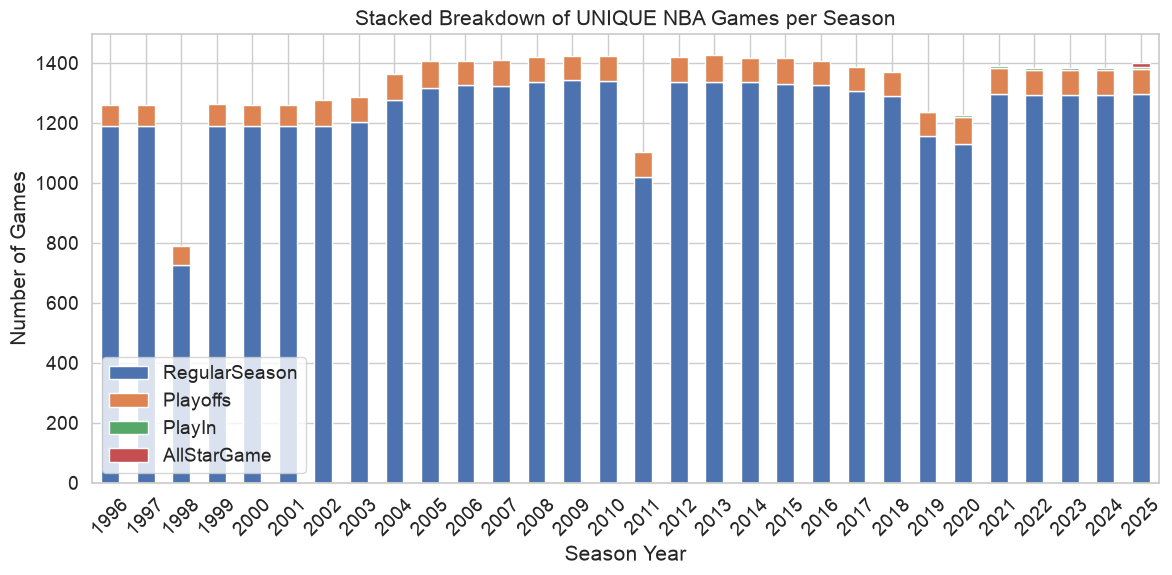

In [22]:
games_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Stacked Breakdown of UNIQUE NBA Games per Season")
plt.xlabel("Season Year")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Noticed that there were many entries with missig data as seen in the code under regarding missing rows, this was resolved later on in the model creation, where only fully filled out values were used as features for the model rather than the other data

In [23]:
# Columns to ignore when checking for missing data
ignore_missing = [
    "CoachId", "OT1Points", "OT2Points", "OTTotalPoints", 
    'game_Label', 'game_SubLabel','Seed'
]

# Columns to check
check_columns = df_nba_full_ext.columns.difference(ignore_missing)

# Identify rows with missing data
missing_rows = df_nba_full_ext[
    df_nba_full_ext[check_columns].isna().any(axis=1)
]

print("\n=== Rows with Missing Data ===")
print("Number of rows with missing data:", len(missing_rows))

# Counter for each missing variable
missing_counts = df_nba_full_ext[check_columns].isna().sum()

# Show each row and which columns are missing
for idx, row in missing_rows.iterrows():
    missing_columns = row[check_columns].index[
        row[check_columns].isna()
    ].tolist()
    # print(f"\nRow index: {idx}")
    # print(f"GameId: {row['gameId']}")
    # print("Missing columns:", missing_columns)

# Remove variables with 0 missing values
missing_counts = missing_counts[missing_counts > 0]

print("\n=== Missing Values by Variable ===")
print(missing_counts)

print("\nTotal missing values:", missing_counts.sum())


=== Rows with Missing Data ===
Number of rows with missing data: 79688

=== Missing Values by Variable ===
+/-                           54
BenchPoints                 7234
BiggestLead                 7234
BiggestScoringRun           7234
DReb%                       7794
FastBreakPoints             7234
OReb%                       7797
OppOReb%                    7794
PointsInPaint               7234
Q1Points                    7234
Q2Points                    7246
Q3Points                    7250
Q4Points                    7250
Reb%                       14457
SeasonLosses                7234
SeasonWins                  7234
SecondChancePoints          7234
TeamReb                     7510
TeamTO                      7510
TimeOutsRemaining           7234
diff_+/-                     106
diff_BenchPoints            7234
diff_BiggestLead            7234
diff_BiggestScoringRun      7234
diff_DReb%                 14458
diff_FastBreakPoints        7234
diff_OReb%                 14462
d

# Step 3: Create Train, Test, Val Splits (Used just df_RegularSeason for Model, called df_rain, df_val, df_test)

#### Building dataframes first

In [24]:
# df_RegularSeason
trainval_list = []
test_list = []
for season, season_df in df_RegularSeason.groupby("game_SeasonYear"):
    season_trainval, season_test = train_test_split(season_df,train_size = 0.9,
                                                    test_size = 0.1,random_state = 1, 
                                                    shuffle = True)
    trainval_list.append(season_trainval)
    test_list.append(season_test)

df_trainval = pd.concat(trainval_list)
df_test = pd.concat(test_list)

train_list = []
val_list = []

for season, season_df in df_trainval.groupby("game_SeasonYear"):
    season_train, season_val = train_test_split(season_df, train_size = 0.80, test_size = 0.20, random_state = 1, shuffle = True)

    train_list.append(season_train)
    val_list.append(season_val)

df_train = pd.concat(train_list)
df_val = pd.concat(val_list)

# End up with 3 datasets 
# df_train 
# df_val
# df_test 

#### Debugging

In [25]:
# Count UNIQUE games per season
games_train = (
    df_train
    .groupby("game_SeasonYear")["game_Id"]
    .nunique()
)

games_val = (
    df_val
    .groupby("game_SeasonYear")["game_Id"]
    .nunique()
)

games_test = (
    df_test
    .groupby("game_SeasonYear")["game_Id"]
    .nunique()
)

# Combine into one DataFrame
games_summary = pd.DataFrame({
    "Train": games_train,
    "Val": games_val,
    "Test": games_test,
}).fillna(0).astype(int)


print("Number of UNIQUE games per NBA season:")
print(games_summary)

Number of UNIQUE games per NBA season:
                 Train  Val  Test
game_SeasonYear                  
1996              1092  385   223
1997              1092  385   223
1998               666  237   135
1999              1092  385   223
2000              1092  385   223
2001              1092  385   223
2002              1092  385   223
2003              1113  394   228
2004              1177  419   241
2005              1211  429   248
2006              1224  430   253
2007              1208  428   249
2008              1222  430   251
2009              1238  445   255
2010              1235  436   255
2011               942  329   194
2012              1222  430   251
2013              1244  444   255
2014              1240  443   254
2015              1221  431   251
2016              1224  430   253
2017              1204  420   252
2018              1192  425   247
2019              1063  384   218
2020              1048  377   219
2021              1202  422   252
2022     

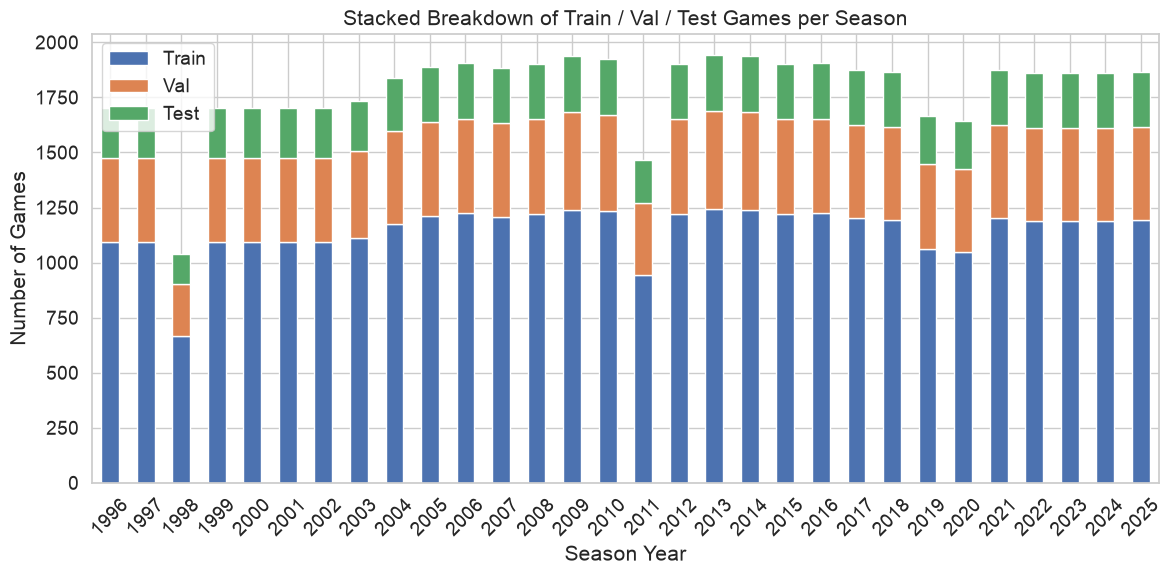

In [26]:
games_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Stacked Breakdown of Train / Val / Test Games per Season")
plt.xlabel("Season Year")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Step 4: XG Boosting Model

### Attempt 1: Tried all features

In [27]:
# cols_to_keep1= [ 
#     # 'game_LeadChanges', 'game_TimesTied', 
#     'Win', 'OpponentScore', 'TeamScore', 
#     'Ast', 'Blk', 'Stl', 
#     'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA', 'FT%', 
#     'DReb','OReb', 'TReb', 
#     'PF', 'TO', 
#     # '+/-',
#     'Q1Points', 'Q2Points','Q3Points', 'Q4Points', 'BenchPoints', 
#     # 'BiggestLead',
#     'BiggestScoringRun',
#     'FastBreakPoints', 'PointsInPaint', 'SecondChancePoints',
#     # 'TimeOutsRemaining',
#     # 'SeasonWins', 'SeasonLosses', 'CoachId',
#     # 'Seed', 
#     'TeamReb',
#     # 'TeamTO', 
#     # 'OT1Points', 'OT2Points', 'OTTotalPoints', 
#     'PFDrawn', 
#     # 'EstOffRTG', 'OffRTG', 'EstDefRTG', 'DefRTG', 'EstNetRTG', 'NetRTG',
#     'AST%', 'A/TO', 'AstRatio', 'OReb%', 'DReb%', 'Reb%',
#     # 'TeamTO%', 
#     # 'eFG%', 
#     'TS%', 'EstPace', 'Pace', 'PacePer40', 
#     'Possessions', 
#     # 'PlayerImpactEstimate',
#     'PointsOffTO',
#         'OppPointsOffTO', 'OppPointsSecondChance', 'OppPointsFastBreak',
#         'OppPointsInPaint', '%2PT_FGA', '%3PT_FGA', '%Points_2PT',
#             '%Points_2PT_MidRange', '%Points_3PT', '%Points_FastBreak', 
#             '%Points_FreeThrow', '%Points_OffTO', '%Points_InPaint',
#                 '%Assisted_2PT_Made', '%Unassisted_2PT_Made',
#        '%Assisted_3PT_Made', '%Unassisted_3PT_Made',
#            '%Assisted_FGM', '%Unassisted_FGM', 'FTA_Rate',
#         # 'OppEffFG%',
#         'OppFTA_Rate', 'OppTO%', 'OppOReb%',
#     'diff_Ast', 'diff_Blk', 'diff_Stl', 
#     # 'diff_FGM', 
#     'diff_FGA', 
#     # 'diff_FG%', 
#     'diff_3PM', 'diff_3PA',
#     'diff_3P%', 'diff_FTM', 'diff_FTA', 'diff_FT%', 
#     'diff_DReb', 'diff_OReb', 'diff_TReb', 'diff_PF', 
#         'diff_TO', 
#         #'diff_+/-',
#          'diff_Q1Points', 'diff_Q2Points'
#         , 'diff_Q3Points', 'diff_Q4Points', 'diff_BenchPoints',
#         # 'diff_BiggestLead', 
#         'diff_BiggestScoringRun'
#         , 'diff_FastBreakPoints', 'diff_PointsInPaint',
#         'diff_SecondChancePoints', 
#         # 'diff_TimeOutsRemaining',
#     'diff_TeamReb', 
#     # 'diff_TeamTO', 
#     # 'diff_OT1Points', 'diff_OT2Points', 'diff_OTTotalPoints',
#     'diff_PFDrawn', 
#     # 'diff_EstOffRTG', 'diff_OffRTG', 'diff_EstDefRTG', 'diff_DefRTG', 'diff_EstNetRTG', 'diff_NetRTG',
#     'diff_AST%', 'diff_A/TO',
#     'diff_AstRatio', 'diff_OReb%', 'diff_DReb%',
#     'diff_Reb%', 
#     # 'diff_TeamTO%', 
#     # 'diff_eFG%', 
#     # 'diff_TS%', 
#     'diff_EstPace', 'diff_Pace', 'diff_PacePer40',
#     'diff_Possessions', 
#     # 'diff_PlayerImpactEstimate', 
#     'diff_PointsOffTO', 'diff_OppPointsOffTO', 
#     'diff_OppPointsSecondChance', 'diff_OppPointsFastBreak',
#     'diff_OppPointsInPaint', 'diff_%2PT_FGA', 'diff_%3PT_FGA',
#         'diff_%Points_2PT', 'diff_%Points_2PT_MidRange',
#         'diff_%Points_3PT', 'diff_%Points_FastBreak', 
#         'diff_%Points_FreeThrow', 'diff_%Points_OffTO', 
#         'diff_%Points_InPaint', 'diff_%Assisted_2PT_Made', 
#         'diff_%Unassisted_2PT_Made', 'diff_%Assisted_3PT_Made',
#             'diff_%Unassisted_3PT_Made', 'diff_%Assisted_FGM',
#             'diff_%Unassisted_FGM', 'diff_FTA_Rate', 
#             # 'diff_OppEffFG%',
#             'diff_OppFTA_Rate', 'diff_OppTO%',
#                 'diff_OppOReb%',]

### Attempt 2: Remove Redundancies

In [28]:
cols_to_keep2 = [ 
    # Game Stats
    'Win', 
    # 'OpponentScore', 'TeamScore',

    # Basic Stats
    'Ast', 'Blk', 'Stl', 
    'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA', 'FT%',
    'DReb', 'OReb', 'TReb',
    'PF', 'TO',

    # 'Q1Points', 'Q2Points', 'Q3Points', 'Q4Points',
    'BenchPoints', 'BiggestScoringRun', 'FastBreakPoints', 'PointsInPaint', 'SecondChancePoints', 'PointsOffTO',

    'TeamReb', 'PFDrawn',
    'AST%', 'A/TO', 'AstRatio', 'TeamTO%',
    'OReb%', 'DReb%', 'Reb%',
    # 'TS%', 
    'FTA_Rate',

    'EstPace', 'Pace', 'PacePer40', 'Possessions',

    'OppPointsOffTO', 'OppPointsSecondChance', 'OppPointsFastBreak', 'OppPointsInPaint',
    'OppFTA_Rate', 'OppTO%', 'OppOReb%',

    '%2PT_FGA', '%3PT_FGA', '%Points_2PT', '%Points_2PT_MidRange', '%Points_3PT', '%Points_FastBreak',
    '%Points_FreeThrow', '%Points_OffTO', '%Points_InPaint',
    '%Assisted_2PT_Made', '%Unassisted_2PT_Made',
    '%Assisted_3PT_Made', '%Unassisted_3PT_Made',
    '%Assisted_FGM', '%Unassisted_FGM',

    # Differentials
    'diff_Ast', 'diff_Blk', 'diff_Stl',
    'diff_FGA',
    'diff_3PM', 'diff_3PA', 'diff_3P%',
    'diff_FTM', 'diff_FTA', 'diff_FT%',
    'diff_DReb', 'diff_OReb', 'diff_TReb',
    'diff_PF', 'diff_TO',

    # 'diff_Q1Points', 'diff_Q2Points', 'diff_Q3Points', 'diff_Q4Points',
    'diff_BenchPoints', 'diff_BiggestScoringRun',
    'diff_FastBreakPoints', 'diff_PointsInPaint', 'diff_SecondChancePoints', 'diff_PointsOffTO',
    'diff_OppPointsOffTO', 'diff_OppPointsSecondChance', 'diff_OppPointsFastBreak', 'diff_OppPointsInPaint',
    'diff_TeamReb', 'diff_PFDrawn',

    'diff_AST%', 'diff_A/TO', 'diff_AstRatio',
    'diff_OReb%', 'diff_DReb%', 'diff_Reb%',
    'diff_TeamTO%', 
    # 'diff_TS%', 
    'diff_FTA_Rate',

    'diff_EstPace', 'diff_Pace', 'diff_PacePer40', 'diff_Possessions',

    'diff_%2PT_FGA', 'diff_%3PT_FGA',
    'diff_%Points_2PT', 'diff_%Points_2PT_MidRange', 'diff_%Points_3PT', 'diff_%Points_FastBreak',  
    'diff_%Points_FreeThrow', 'diff_%Points_OffTO', 'diff_%Points_InPaint',
    'diff_%Assisted_2PT_Made', 'diff_%Unassisted_2PT_Made',
    'diff_%Assisted_3PT_Made', 'diff_%Unassisted_3PT_Made',
    'diff_%Assisted_FGM', 'diff_%Unassisted_FGM',

    'diff_OppFTA_Rate', 'diff_OppTO%', 'diff_OppOReb%',
]

### Attempt 3: Just keep Diff features

In [29]:
cols_to_keep3 = [ 
    # Game Stats
    'Win', 

    # Differentials
    'diff_Ast', 'diff_Blk', 'diff_Stl',
    'diff_FGA',
    'diff_3PM', 'diff_3PA', 'diff_3P%',
    'diff_FTM', 'diff_FTA', 'diff_FT%',
    'diff_DReb', 'diff_OReb', 'diff_TReb',
    'diff_PF', 'diff_TO',

    'diff_BenchPoints', 'diff_BiggestScoringRun',
    'diff_FastBreakPoints', 'diff_PointsInPaint', 'diff_SecondChancePoints', 'diff_PointsOffTO',
    'diff_OppPointsOffTO', 'diff_OppPointsSecondChance', 'diff_OppPointsFastBreak', 'diff_OppPointsInPaint',
    'diff_TeamReb', 'diff_PFDrawn',

    'diff_AST%', 'diff_A/TO', 
    'diff_OReb%', 'diff_DReb%', 'diff_Reb%',
    'diff_TeamTO%', 
    'diff_FTA_Rate',

    'diff_EstPace', 'diff_Pace', 'diff_PacePer40', 'diff_Possessions',

    'diff_%2PT_FGA', 'diff_%3PT_FGA',
    'diff_%Points_2PT', 'diff_%Points_2PT_MidRange', 'diff_%Points_3PT', 'diff_%Points_FastBreak',  
    'diff_%Points_FreeThrow', 'diff_%Points_OffTO', 'diff_%Points_InPaint',
    'diff_%Assisted_2PT_Made', 'diff_%Unassisted_2PT_Made',
    'diff_%Assisted_3PT_Made', 'diff_%Unassisted_3PT_Made',
    'diff_%Assisted_FGM', 'diff_%Unassisted_FGM',

    'diff_OppFTA_Rate', 'diff_OppTO%', 'diff_OppOReb%',
]

Create X_train, Y_train, X_val, Y_val, X_test, Y_test

In [30]:
# # Create X_train, Y_train, X_val, Y_val, X_test, Y_test
# df_train , df_val, df_test = df_train[cols_to_keep3], df_val[cols_to_keep3], df_test[cols_to_keep3]

# # Building X, y train test val data
# X_train , Y_train = df_train.drop(columns = ['Win']), df_train['Win']
# X_val, Y_val = df_val.drop(columns = ['Win']),  df_val['Win']
# X_test, Y_test = df_test.drop(columns = ['Win']), df_test['Win']

Grid Search For Parameters

Prediction (Best Params have been pasted under to prevent long runtie in grid search)

In [31]:
# Found from Gridsearch
# best_params = {
#     'colsample_bytree': 1.0,
#     'learning_rate': 0.2,
#     'max_depth': 7,
#     'n_estimators': 200,
#     'subsample': 1.0
# }

# best_model = xgb.XGBClassifier(**best_params, eval_metric = "logloss", early_stopping_rounds = 25)
# best_model.fit(X_train, Y_train, eval_set = [(X_train, Y_train),(X_val, Y_val)], verbose = False)

# Y_hat = best_model.predict(X_test)
# Y_prob = best_model.predict_proba(X_test)[:,1]

Summary Stats with SHAP

In [32]:
# import shap
# Y_hat = best_model.predict(X_test)

# print("Accuracy score: ", accuracy_score(Y_test, Y_hat))
# print("\n\nConfusion Matrix\n: ", confusion_matrix(Y_test, Y_hat))

# Y_prob = best_model.predict_proba(X_test)[:, 1]

# print("\n" )
# print("AUC:        ", round(roc_auc_score(Y_test, Y_prob), 4))
# print("Log Loss:   ", round(log_loss(Y_test, Y_prob), 4))
# print("Accuracy:   ", round(accuracy_score(Y_test, Y_hat), 4))
# print("Brier:      ", round(brier_score_loss(Y_test, Y_prob), 4))

# explainer = shap.TreeExplainer(best_model)

# shap_values = explainer.shap_values(X_test)

# shap_importance = pd.DataFrame({
#     "Feature": X_test.columns,
#     "MeanAbsSHAP": np.abs(shap_values).mean(axis=0)
# }).sort_values(
#     "MeanAbsSHAP",
#     ascending=False
# )

# print("\n" + "="*60)
# print("SHAP Feature Importance")

# print(shap_importance.to_string(index=False))

# shap.summary_plot(
#     shap_values,
#     X_test,
#     plot_type="bar"
# )

# shap.summary_plot(
#     shap_values,
#     X_test
# )

### Attempt 4: Create 5 different models

#### Model for Shooting, Rebounding, Scoring, Defense, Pace, Playmaking

In [33]:
col_Shooting = [ 
    'Win',
    'FGA', 
    '3PM', '3PA', 'FTA', 'FT%', 
    'PFDrawn',
    '%Points_2PT', '%Points_2PT_MidRange', '%Points_3PT', '%Points_FreeThrow', 
]

col_Rebounding = [ 
    'Win',
    'OReb', 'DReb',
    'OppPointsSecondChance',
]

col_Scoring = [ 
    'Win', 
    '%Points_FastBreak', '%Points_OffTO', '%Points_InPaint',
]

col_Defense = [ 
    'Win',
    'Blk', 'Stl',
    'PF', 
    'OpponentScore',
    'OppPointsFastBreak', 'OppPointsInPaint',
    'OppEffFG%',
    'OppFTA_Rate', 'OppTO%',
    'PointsOffTO',
    'OppPointsSecondChance',
]

col_Pace = [ 
    'Win',
    'Pace', 
]

col_Playmaking = [ 
    'Win',
    'Ast', 
    'TO', 
    'TeamTO', 
    'AST%', 'A/TO',
    '%Assisted_2PT_Made', '%Assisted_3PT_Made', '%Assisted_FGM'
]

In [34]:
# Shooting
X_train_Sho = df_train[col_Shooting].drop(columns = ['Win'])
Y_train_Sho = df_train['Win']

X_val_Sho = df_val[col_Shooting].drop(columns = ['Win'])
Y_val_Sho = df_val['Win']

X_test_Sho = df_test[col_Shooting].drop(columns = ['Win'])
Y_test_Sho = df_test['Win']

# Rebouding
X_train_Reb = df_train[col_Rebounding].drop(columns = ['Win'])
Y_train_Reb = df_train['Win']

X_val_Reb = df_val[col_Rebounding].drop(columns = ['Win'])
Y_val_Reb = df_val['Win']

X_test_Reb = df_test[col_Rebounding].drop(columns = ['Win'])
Y_test_Reb = df_test['Win']

# Scoring
X_train_Sco = df_train[col_Scoring].drop(columns = ['Win'])
Y_train_Sco = df_train['Win']

X_val_Sco = df_val[col_Scoring].drop(columns = ['Win'])
Y_val_Sco = df_val['Win']

X_test_Sco = df_test[col_Scoring].drop(columns = ['Win'])
Y_test_Sco = df_test['Win']

# Defense
X_train_Def = df_train[col_Defense].drop(columns = ['Win'])
Y_train_Def = df_train['Win']

X_val_Def = df_val[col_Defense].drop(columns = ['Win'])
Y_val_Def = df_val['Win']

X_test_Def = df_test[col_Defense].drop(columns = ['Win'])
Y_test_Def = df_test['Win']

# Pace
X_train_Pac = df_train[col_Pace].drop(columns = ['Win'])
Y_train_Pac = df_train['Win']

X_val_Pac = df_val[col_Pace].drop(columns = ['Win'])
Y_val_Pac = df_val['Win']

X_test_Pac = df_test[col_Pace].drop(columns = ['Win'])
Y_test_Pac = df_test['Win']

# Playmaking
X_train_Pla = df_train[col_Playmaking].drop(columns = ['Win'])
Y_train_Pla = df_train['Win']

X_val_Pla = df_val[col_Playmaking].drop(columns = ['Win'])
Y_val_Pla = df_val['Win']

X_test_Pla = df_test[col_Playmaking].drop(columns = ['Win'])
Y_test_Pla = df_test['Win']


In [ ]:
# Shooting
best_params_Sho = {
    'colsample_bytree': 1.0,
    'learning_rate': 0.05,
    'max_depth': 3,
    'n_estimators': 600,
    'subsample': 0.8
}

model_Sho = xgb.XGBClassifier(eval_metric = 'logloss', random_state = 1, n_jobs = 1, **best_params_Sho)
model_Sho.fit(X_train_Sho, Y_train_Sho)

In [ ]:
best_params_Reb = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 600,
    'subsample': 0.8
}

# Rebounding
model_Reb = xgb.XGBClassifier(eval_metric = 'logloss', random_state = 1, n_jobs = 1, **best_params_Reb)
model_Reb.fit(X_train_Reb, Y_train_Reb)

In [ ]:
# Scoring
best_params_Sco = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.3,
    'max_depth': 3,
    'n_estimators': 200,
    'subsample': 0.8
}

model_Sco = xgb.XGBClassifier(eval_metric = 'logloss', random_state = 1, n_jobs = 1, **best_params_Sco)
model_Sco.fit(X_train_Sco, Y_train_Sco)

In [ ]:
# Defense
best_params_Def = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.03,
    'max_depth': 3,
    'n_estimators': 600,
    'subsample': 0.8
}

model_Def= xgb.XGBClassifier(eval_metric = 'logloss', random_state = 1, n_jobs = 1, **best_params_Def)
model_Def.fit(X_train_Def, Y_train_Def)

In [ ]:
# Pace
best_params_Pac = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 200,
    'subsample': 1.0
}
model_Pac= xgb.XGBClassifier(eval_metric = 'logloss', random_state = 1, n_jobs = 1, **best_params_Pac)
model_Pac.fit(X_train_Pac, Y_train_Pac)

In [ ]:
# Playmaking
best_params_Pla = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.05,
    'max_depth': 3,
    'n_estimators': 200,
    'subsample': 0.8
}
model_Pla = xgb.XGBClassifier(eval_metric = 'logloss', random_state = 1, n_jobs = 1, **best_params_Pla)
model_Pla.fit(X_train_Pla, Y_train_Pla)

In [41]:
# Put model and data into dictionaries
models = {
    'Shooting': model_Sho,
    'Rebounding': model_Reb,
    'Scoring': model_Sco,
    'Defense': model_Def,
    'Pace': model_Pac,
    'Playmaking': model_Pla
}

test_datasets = {
    'Shooting': (X_test_Sho, Y_test_Sho),
    'Rebounding': (X_test_Reb, Y_test_Reb),
    'Scoring': (X_test_Sco, Y_test_Sco),
    'Defense': (X_test_Def, Y_test_Def),
    'Pace': (X_test_Pac, Y_test_Pac),
    'Playmaking': (X_test_Pla, Y_test_Pla)
}

datasets = {
    'Shooting': (X_train_Sho, Y_train_Sho, X_val_Sho, Y_val_Sho, X_test_Sho, Y_test_Sho),
    'Rebounding': (X_train_Reb, Y_train_Reb, X_val_Reb, Y_val_Reb, X_test_Reb, Y_test_Reb),
    'Scoring': (X_train_Sco, Y_train_Sco, X_val_Sco, Y_val_Sco, X_test_Sco, Y_test_Sco),
    'Defense': (X_train_Def, Y_train_Def, X_val_Def, Y_val_Def, X_test_Def, Y_test_Def),
    'Pace': (X_train_Pac, Y_train_Pac, X_val_Pac, Y_val_Pac, X_test_Pac, Y_test_Pac),
    'Playmaking': (X_train_Pla, Y_train_Pla, X_val_Pla, Y_val_Pla, X_test_Pla, Y_test_Pla)
}

#### Plotting SHAP Importance for each features

In [ ]:
# Loop through
shap_results = {}

for category, model in models.items():

    X_test, Y_test = test_datasets[category]

    # Predictions
    Y_hat = model.predict(X_test)
    Y_prob = model.predict_proba(X_test)[:, 1]

    print(f"{category} Model")

    print("Accuracy: ", round(accuracy_score(Y_test, Y_hat), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(Y_test, Y_hat))

    print("\nAUC:      ", round(roc_auc_score(Y_test, Y_prob), 4))
    print("Log Loss: ", round(log_loss(Y_test, Y_prob), 4))
    print("Accuracy: ", round(accuracy_score(Y_test, Y_hat), 4))
    print("Brier:    ", round(brier_score_loss(Y_test, Y_prob), 4))
    
    # SHAP
    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_test)

    shap_importance = pd.DataFrame({
        "Feature": X_test.columns,
        "MeanAbsSHAP": np.abs(shap_values).mean(axis=0)
    }).sort_values(
        "MeanAbsSHAP",
        ascending=False
    )

    # Save results
    shap_results[category] = shap_importance

    print("\nSHAP Feature Importance:")
    print(shap_importance.to_string(index=False))

    # SHAP Plots
    shap.summary_plot(
        shap_values,
        X_test,
        plot_type="bar"
    )

    shap.summary_plot(
        shap_values,
        X_test
    )

#### PDP Plots for each feature in each model

In [ ]:
for category, model in models.items():

    X_test, Y_test = test_datasets[category]

    features = list(X_test.columns)

    # Calculate number of rows needed
    n_features = len(features)
    n_cols = 2
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(16, 5 * n_rows)
    )

    # Make axes iterable even if there is only one row
    axes = np.array(axes).flatten()

    # Create PDP for every feature
    PartialDependenceDisplay.from_estimator(
        model,
        X_test,
        features,
        ax=axes[:n_features],
        grid_resolution=30
    )

    # Format plots
    for i, feature in enumerate(features):

        axes[i].set_title(
            feature,
            fontsize=14,
            fontweight="bold"
        )

        axes[i].set_ylabel(
            "Predicted Win Probability"
        )

        axes[i].set_ylim(0, 1)

        axes[i].set_yticks(
            np.arange(0, 1.1, 0.2)
        )

        axes[i].set_yticklabels(
            [f"{int(x * 100)}%" for x in np.arange(0, 1.1, 0.2)]
        )

        axes[i].grid(
            axis="y",
            linestyle="--",
            alpha=0.25
        )

        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)

    # Hide unused subplots
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle(
        f"Partial Dependence Plots — {category} Model",
        fontsize=24,
        fontweight="bold",
        y=1.01
    )

    plt.tight_layout()

    plt.show()

### Attempt 5: Same categories but with diff features

In [44]:
col_Shooting_diff = [
    'Win',
    'diff_FGA',
    'diff_3PM', 'diff_3PA', 'diff_3P%',
    'diff_FTM', 'diff_FTA', 'diff_FT%',
    'diff_FTA_Rate',
    'diff_PFDrawn',
    'diff_%2PT_FGA', 'diff_%3PT_FGA',
    'diff_%Points_2PT', 'diff_%Points_2PT_MidRange', 'diff_%Points_3PT', 'diff_%Points_FreeThrow',
]

col_Rebounding_diff = [
    'Win',
    'diff_OReb', 'diff_DReb', 'diff_TReb', 'diff_TeamReb',
    'diff_OReb%', 'diff_DReb%', 'diff_Reb%',
    'diff_SecondChancePoints',
    'diff_OppPointsSecondChance',
]

col_Scoring_diff = [
    'Win',
    'diff_%Points_FastBreak', 'diff_%Points_OffTO', 'diff_%Points_InPaint',
    'diff_FastBreakPoints', 'diff_PointsInPaint',
    'diff_BenchPoints', 'diff_BiggestScoringRun',
]

col_Defense_diff = [
    'Win',
    'diff_Blk', 'diff_Stl', 'diff_PF',
    'diff_PointsOffTO', 'diff_OppPointsOffTO',
    'diff_OppPointsFastBreak', 'diff_OppPointsInPaint', 'diff_OppPointsSecondChance',
    'diff_OppFTA_Rate', 'diff_OppTO%', 'diff_OppOReb%',
]

col_Pace_diff = [
    'Win',
    'diff_Pace', 'diff_EstPace', 'diff_PacePer40', 'diff_Possessions',
]

col_Playmaking_diff = [
    'Win',
    'diff_Ast', 'diff_TO', 'diff_TeamTO%',
    'diff_AST%', 'diff_A/TO',
    'diff_%Assisted_2PT_Made', 'diff_%Unassisted_2PT_Made',
    'diff_%Assisted_3PT_Made', 'diff_%Unassisted_3PT_Made',
    'diff_%Assisted_FGM', 'diff_%Unassisted_FGM',
]

Data splits (diff versions)

In [45]:
# Shooting
X_train_Sho_d = df_train[col_Shooting_diff].drop(columns=['Win'])
Y_train_Sho_d = df_train['Win']

X_val_Sho_d = df_val[col_Shooting_diff].drop(columns=['Win'])
Y_val_Sho_d = df_val['Win']

X_test_Sho_d = df_test[col_Shooting_diff].drop(columns=['Win'])
Y_test_Sho_d = df_test['Win']

# Rebounding
X_train_Reb_d = df_train[col_Rebounding_diff].drop(columns=['Win'])
Y_train_Reb_d = df_train['Win']

X_val_Reb_d = df_val[col_Rebounding_diff].drop(columns=['Win'])
Y_val_Reb_d = df_val['Win']

X_test_Reb_d = df_test[col_Rebounding_diff].drop(columns=['Win'])
Y_test_Reb_d = df_test['Win']

# Scoring
X_train_Sco_d = df_train[col_Scoring_diff].drop(columns=['Win'])
Y_train_Sco_d = df_train['Win']

X_val_Sco_d = df_val[col_Scoring_diff].drop(columns=['Win'])
Y_val_Sco_d = df_val['Win']

X_test_Sco_d = df_test[col_Scoring_diff].drop(columns=['Win'])
Y_test_Sco_d = df_test['Win']

# Defense
X_train_Def_d = df_train[col_Defense_diff].drop(columns=['Win'])
Y_train_Def_d = df_train['Win']

X_val_Def_d = df_val[col_Defense_diff].drop(columns=['Win'])
Y_val_Def_d = df_val['Win']

X_test_Def_d = df_test[col_Defense_diff].drop(columns=['Win'])
Y_test_Def_d = df_test['Win']

# Pace
X_train_Pac_d = df_train[col_Pace_diff].drop(columns=['Win'])
Y_train_Pac_d = df_train['Win']

X_val_Pac_d = df_val[col_Pace_diff].drop(columns=['Win'])
Y_val_Pac_d = df_val['Win']

X_test_Pac_d = df_test[col_Pace_diff].drop(columns=['Win'])
Y_test_Pac_d = df_test['Win']

# Playmaking
X_train_Pla_d = df_train[col_Playmaking_diff].drop(columns=['Win'])
Y_train_Pla_d = df_train['Win']

X_val_Pla_d = df_val[col_Playmaking_diff].drop(columns=['Win'])
Y_val_Pla_d = df_val['Win']

X_test_Pla_d = df_test[col_Playmaking_diff].drop(columns=['Win'])
Y_test_Pla_d = df_test['Win']

Models reusing same tuned hyperparameters as originals

In [ ]:
# Shooting
best_params_Sho_d = {
    'colsample_bytree': 1.0,
    'learning_rate': 0.05,
    'max_depth': 3,
    'n_estimators': 600,
    'subsample': 0.8
}
model_Sho_d = xgb.XGBClassifier(eval_metric='logloss', random_state=1, n_jobs=1, **best_params_Sho_d)
model_Sho_d.fit(X_train_Sho_d, Y_train_Sho_d)

# Rebounding
best_params_Reb_d = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 600,
    'subsample': 0.8
}
model_Reb_d = xgb.XGBClassifier(eval_metric='logloss', random_state=1, n_jobs=1, **best_params_Reb_d)
model_Reb_d.fit(X_train_Reb_d, Y_train_Reb_d)

# Scoring
best_params_Sco_d = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.3,
    'max_depth': 3,
    'n_estimators': 200,
    'subsample': 0.8
}
model_Sco_d = xgb.XGBClassifier(eval_metric='logloss', random_state=1, n_jobs=1, **best_params_Sco_d)
model_Sco_d.fit(X_train_Sco_d, Y_train_Sco_d)

# Defense
best_params_Def_d = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.03,
    'max_depth': 3,
    'n_estimators': 600,
    'subsample': 0.8
}
model_Def_d = xgb.XGBClassifier(eval_metric='logloss', random_state=1, n_jobs=1, **best_params_Def_d)
model_Def_d.fit(X_train_Def_d, Y_train_Def_d)

# Pace
best_params_Pac_d = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 200,
    'subsample': 1.0
}
model_Pac_d = xgb.XGBClassifier(eval_metric='logloss', random_state=1, n_jobs=1, **best_params_Pac_d)
model_Pac_d.fit(X_train_Pac_d, Y_train_Pac_d)

# Playmaking
best_params_Pla_d = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.05,
    'max_depth': 3,
    'n_estimators': 200,
    'subsample': 0.8
}
model_Pla_d = xgb.XGBClassifier(eval_metric='logloss', random_state=1, n_jobs=1, **best_params_Pla_d)
model_Pla_d.fit(X_train_Pla_d, Y_train_Pla_d)

In [47]:
# Dictionaries
models_d = {
    'Shooting': model_Sho_d,
    'Rebounding': model_Reb_d,
    'Scoring': model_Sco_d,
    'Defense': model_Def_d,
    'Pace': model_Pac_d,
    'Playmaking': model_Pla_d
}

test_datasets_d = {
    'Shooting': (X_test_Sho_d, Y_test_Sho_d),
    'Rebounding': (X_test_Reb_d, Y_test_Reb_d),
    'Scoring': (X_test_Sco_d, Y_test_Sco_d),
    'Defense': (X_test_Def_d, Y_test_Def_d),
    'Pace': (X_test_Pac_d, Y_test_Pac_d),
    'Playmaking': (X_test_Pla_d, Y_test_Pla_d)
}

datasets_d = {
    'Shooting': (X_train_Sho_d, Y_train_Sho_d, X_val_Sho_d, Y_val_Sho_d, X_test_Sho_d, Y_test_Sho_d),
    'Rebounding': (X_train_Reb_d, Y_train_Reb_d, X_val_Reb_d, Y_val_Reb_d, X_test_Reb_d, Y_test_Reb_d),
    'Scoring': (X_train_Sco_d, Y_train_Sco_d, X_val_Sco_d, Y_val_Sco_d, X_test_Sco_d, Y_test_Sco_d),
    'Defense': (X_train_Def_d, Y_train_Def_d, X_val_Def_d, Y_val_Def_d, X_test_Def_d, Y_test_Def_d),
    'Pace': (X_train_Pac_d, Y_train_Pac_d, X_val_Pac_d, Y_val_Pac_d, X_test_Pac_d, Y_test_Pac_d),
    'Playmaking': (X_train_Pla_d, Y_train_Pla_d, X_val_Pla_d, Y_val_Pla_d, X_test_Pla_d, Y_test_Pla_d)
}

Shap Evaluations

In [ ]:
shap_results_d = {}

for category, model in models_d.items():

    X_test, Y_test = test_datasets_d[category]

    # Predictions
    Y_hat = model.predict(X_test)
    Y_prob = model.predict_proba(X_test)[:, 1]

    print(f"{category} Model (diffs)")

    print("Accuracy: ", round(accuracy_score(Y_test, Y_hat), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(Y_test, Y_hat))

    print("\nAUC:      ", round(roc_auc_score(Y_test, Y_prob), 4))
    print("Log Loss: ", round(log_loss(Y_test, Y_prob), 4))
    print("Accuracy: ", round(accuracy_score(Y_test, Y_hat), 4))
    print("Brier:    ", round(brier_score_loss(Y_test, Y_prob), 4))

    # SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    shap_importance = pd.DataFrame({
        "Feature": X_test.columns,
        "MeanAbsSHAP": np.abs(shap_values).mean(axis=0)
    }).sort_values(
        "MeanAbsSHAP",
        ascending=False
    )

    shap_results_d[category] = shap_importance

    print("\nSHAP Feature Importance:")
    print(shap_importance.to_string(index=False))

    shap.summary_plot(
        shap_values,
        X_test,
        plot_type="bar"
    )

    shap.summary_plot(
        shap_values,
        X_test
    )

Partial Dependence Plots

In [ ]:
for category, model in models_d.items():

    X_test, Y_test = test_datasets_d[category]

    features = list(X_test.columns)

    n_features = len(features)
    n_cols = 2
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(16, 5 * n_rows)
    )

    axes = np.array(axes).flatten()

    PartialDependenceDisplay.from_estimator(
        model,
        X_test,
        features,
        ax=axes[:n_features],
        grid_resolution=30
    )

    for i, feature in enumerate(features):

        axes[i].set_title(feature, fontsize=14, fontweight="bold")
        axes[i].set_ylabel("Predicted Win Probability")
        axes[i].set_ylim(0, 1)
        axes[i].set_yticks(np.arange(0, 1.1, 0.2))
        axes[i].set_yticklabels([f"{int(x * 100)}%" for x in np.arange(0, 1.1, 0.2)])
        axes[i].grid(axis="y", linestyle="--", alpha=0.25)
        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)

    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle(
        f"Partial Dependence Plots — {category} Model (diffs)",
        fontsize=24,
        fontweight="bold",
        y=1.01
    )

    plt.tight_layout()
    plt.show()

### Attempt 6: Model using the most impactful features

#### Modelling

In [27]:
# col_Altogether = [ 
#     'Win',
#     '3PM', '%Points_3PT', 'FTA', 'diff_FTM',
#     '%Points_2PT', '%Points_2PT_MidRange',
#     "diff_OReb",
#     'DReb', 'OppPointsSecondChance',
#     'diff_%Points_InPaint', 'diff_OppPointsInPaint',
#     'OppEffFG%', 'diff_PointsOffTO', 'OpponentScore', 'OppTO%', 'OppFTA_Rate', 'PF', 
#     'OppPointsFastBreak',
#     'Ast', 
#     'TO', '%Assisted_FGM',
# ]

# col_Altogether = [ 
#     'Win',
#     'Ast', 
#     'OppTO%', 
#     'OppEffFG%',
#     'PointsOffTO',
#     'DReb',
#     '3PM', 'FTA', 'FT%',
#     'diff_FTM', 'diff_OReb', 'diff_%Points_InPaint', 'diff_OppPointsInPaint', 'diff_PointsOffTO'
# ]
# col_Altogether = [ 
#     'Win',
#     'Ast', 
#     'OppTO%', 
#     'PointsOffTO',
#     'DReb',
#     '3PM', 'FTA', 'FT%',
#     'diff_FTM', 'diff_OReb', 'diff_%Points_InPaint', 'diff_OppPointsInPaint', 'diff_PointsOffTO'
# ]

col_Altogether = [ 
    'Win',
    'diff_Ast', 'diff_OppPointsInPaint', 'diff_PointsOffTO', 'diff_Blk',
    'diff_DReb', 'diff_FTM', 'diff_3PM', 
]

In [28]:
X_train_Altogether, Y_train_Altogether = df_train[col_Altogether].drop(columns = ['Win']), df_train['Win']
X_val_Altogether, Y_val_Altogether = df_val[col_Altogether].drop(columns = ['Win']), df_val['Win']
X_test_Altogether, Y_test_Altogether = df_test[col_Altogether].drop(columns = ['Win']), df_test['Win']

In [29]:
# # Best param for 1st attempt
# best_params_Altogether = {
#     'colsample_bytree': 1.0,
#     'learning_rate': 0.1,
#     'max_depth': 3,
#     'n_estimators': 150,
#     'subsample': 0.8
# }

# # Best param for 2nd attempt
# best_params_Altogether = {
#     'colsample_bytree': 1.0,
#     'learning_rate': 0.15,
#     'max_depth': 4,
#     'n_estimators': 200,
#     'subsample': 0.7
# }

# # Best param for 3rd attempt
# best_params_Altogether = {
#     'colsample_bytree': 1.0,
#     'learning_rate': 0.15,
#     'max_depth': 4,
#     'n_estimators': 200,
#     'subsample': 0.7
# }

best_params_Altogether = {
    'subsample': 0.6,
    'n_estimators': 300,
    'min_child_weight': 5,
    'max_depth': 6,
    'learning_rate': 0.005,
    'gamma': 0.2,
    'colsample_bytree': 0.5
}



best_model_Altogether = xgb.XGBClassifier(**best_params_Altogether, eval_metric = "logloss", early_stopping_rounds = 25)
best_model_Altogether.fit(X_train_Altogether, Y_train_Altogether, eval_set = [(X_train_Altogether, Y_train_Altogether),(X_val_Altogether, Y_val_Altogether)], verbose = False)

Y_hat_Altogether = best_model_Altogether.predict(X_test_Altogether)

print("Accuracy score: ", accuracy_score(Y_test_Altogether, Y_hat_Altogether))
print("\n\nConfusion Matrix\n: ", confusion_matrix(Y_test_Altogether, Y_hat_Altogether))

Y_prob_Altogether = best_model_Altogether.predict_proba(X_test_Altogether)[:, 1]

print("\n")
print("AUC:        ", round(roc_auc_score(Y_test_Altogether, Y_prob_Altogether), 4))
print("Log Loss:   ", round(log_loss(Y_test_Altogether, Y_prob_Altogether), 4))
print("Accuracy:   ", round(accuracy_score(Y_test_Altogether, Y_hat_Altogether), 4))
print("Brier:      ", round(brier_score_loss(Y_test_Altogether, Y_prob_Altogether), 4))


Accuracy score:  0.8742482961379126


Confusion Matrix
:  [[3248  477]
 [ 464 3294]]


AUC:         0.9516
Log Loss:    0.4293
Accuracy:    0.8742
Brier:       0.1288


#### Plotting SHAP Values


SHAP Feature Importance — Altogether Model:
              Feature  MeanAbsSHAP
            diff_DReb     0.386121
             diff_Ast     0.281361
     diff_PointsOffTO     0.254451
             diff_3PM     0.223643
             diff_FTM     0.196026
diff_OppPointsInPaint     0.144003
             diff_Blk     0.093291


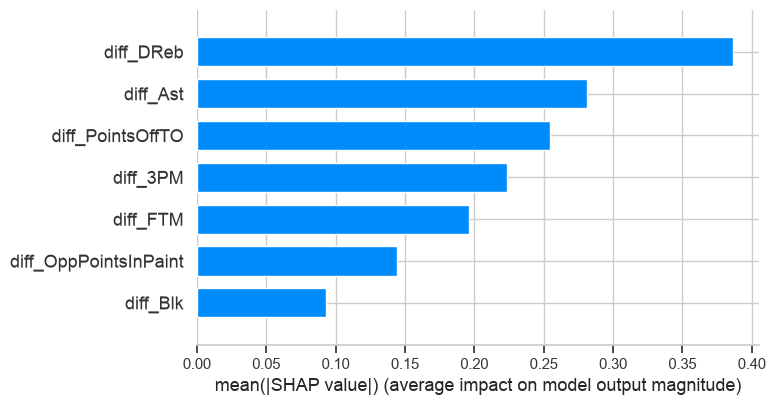

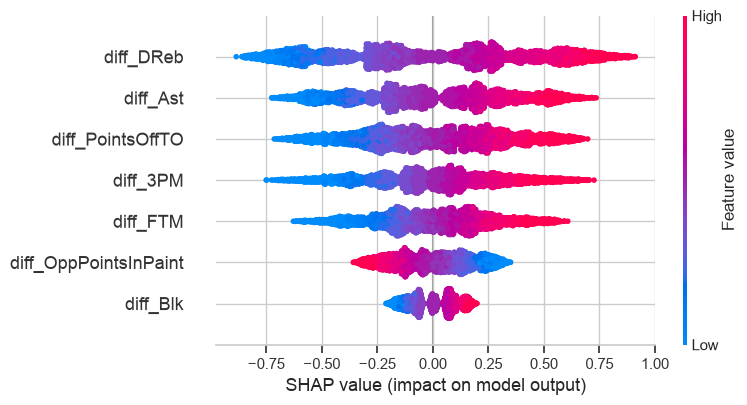

In [30]:
explainer = shap.TreeExplainer(best_model_Altogether)
shap_values = explainer.shap_values(X_test_Altogether)

# SHAP importance table
shap_importance_Altogether = pd.DataFrame({
    "Feature": X_test_Altogether.columns,
    "MeanAbsSHAP": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "MeanAbsSHAP",
    ascending=False
)

print("\nSHAP Feature Importance — Altogether Model:")
print(shap_importance_Altogether.to_string(index=False))

# Bar plot
shap.summary_plot(
    shap_values,
    X_test_Altogether,
    plot_type="bar",
    show=True
)

# Beeswarm plot
shap.summary_plot(
    shap_values,
    X_test_Altogether,
    show=True
)


Plotting PDP Plots

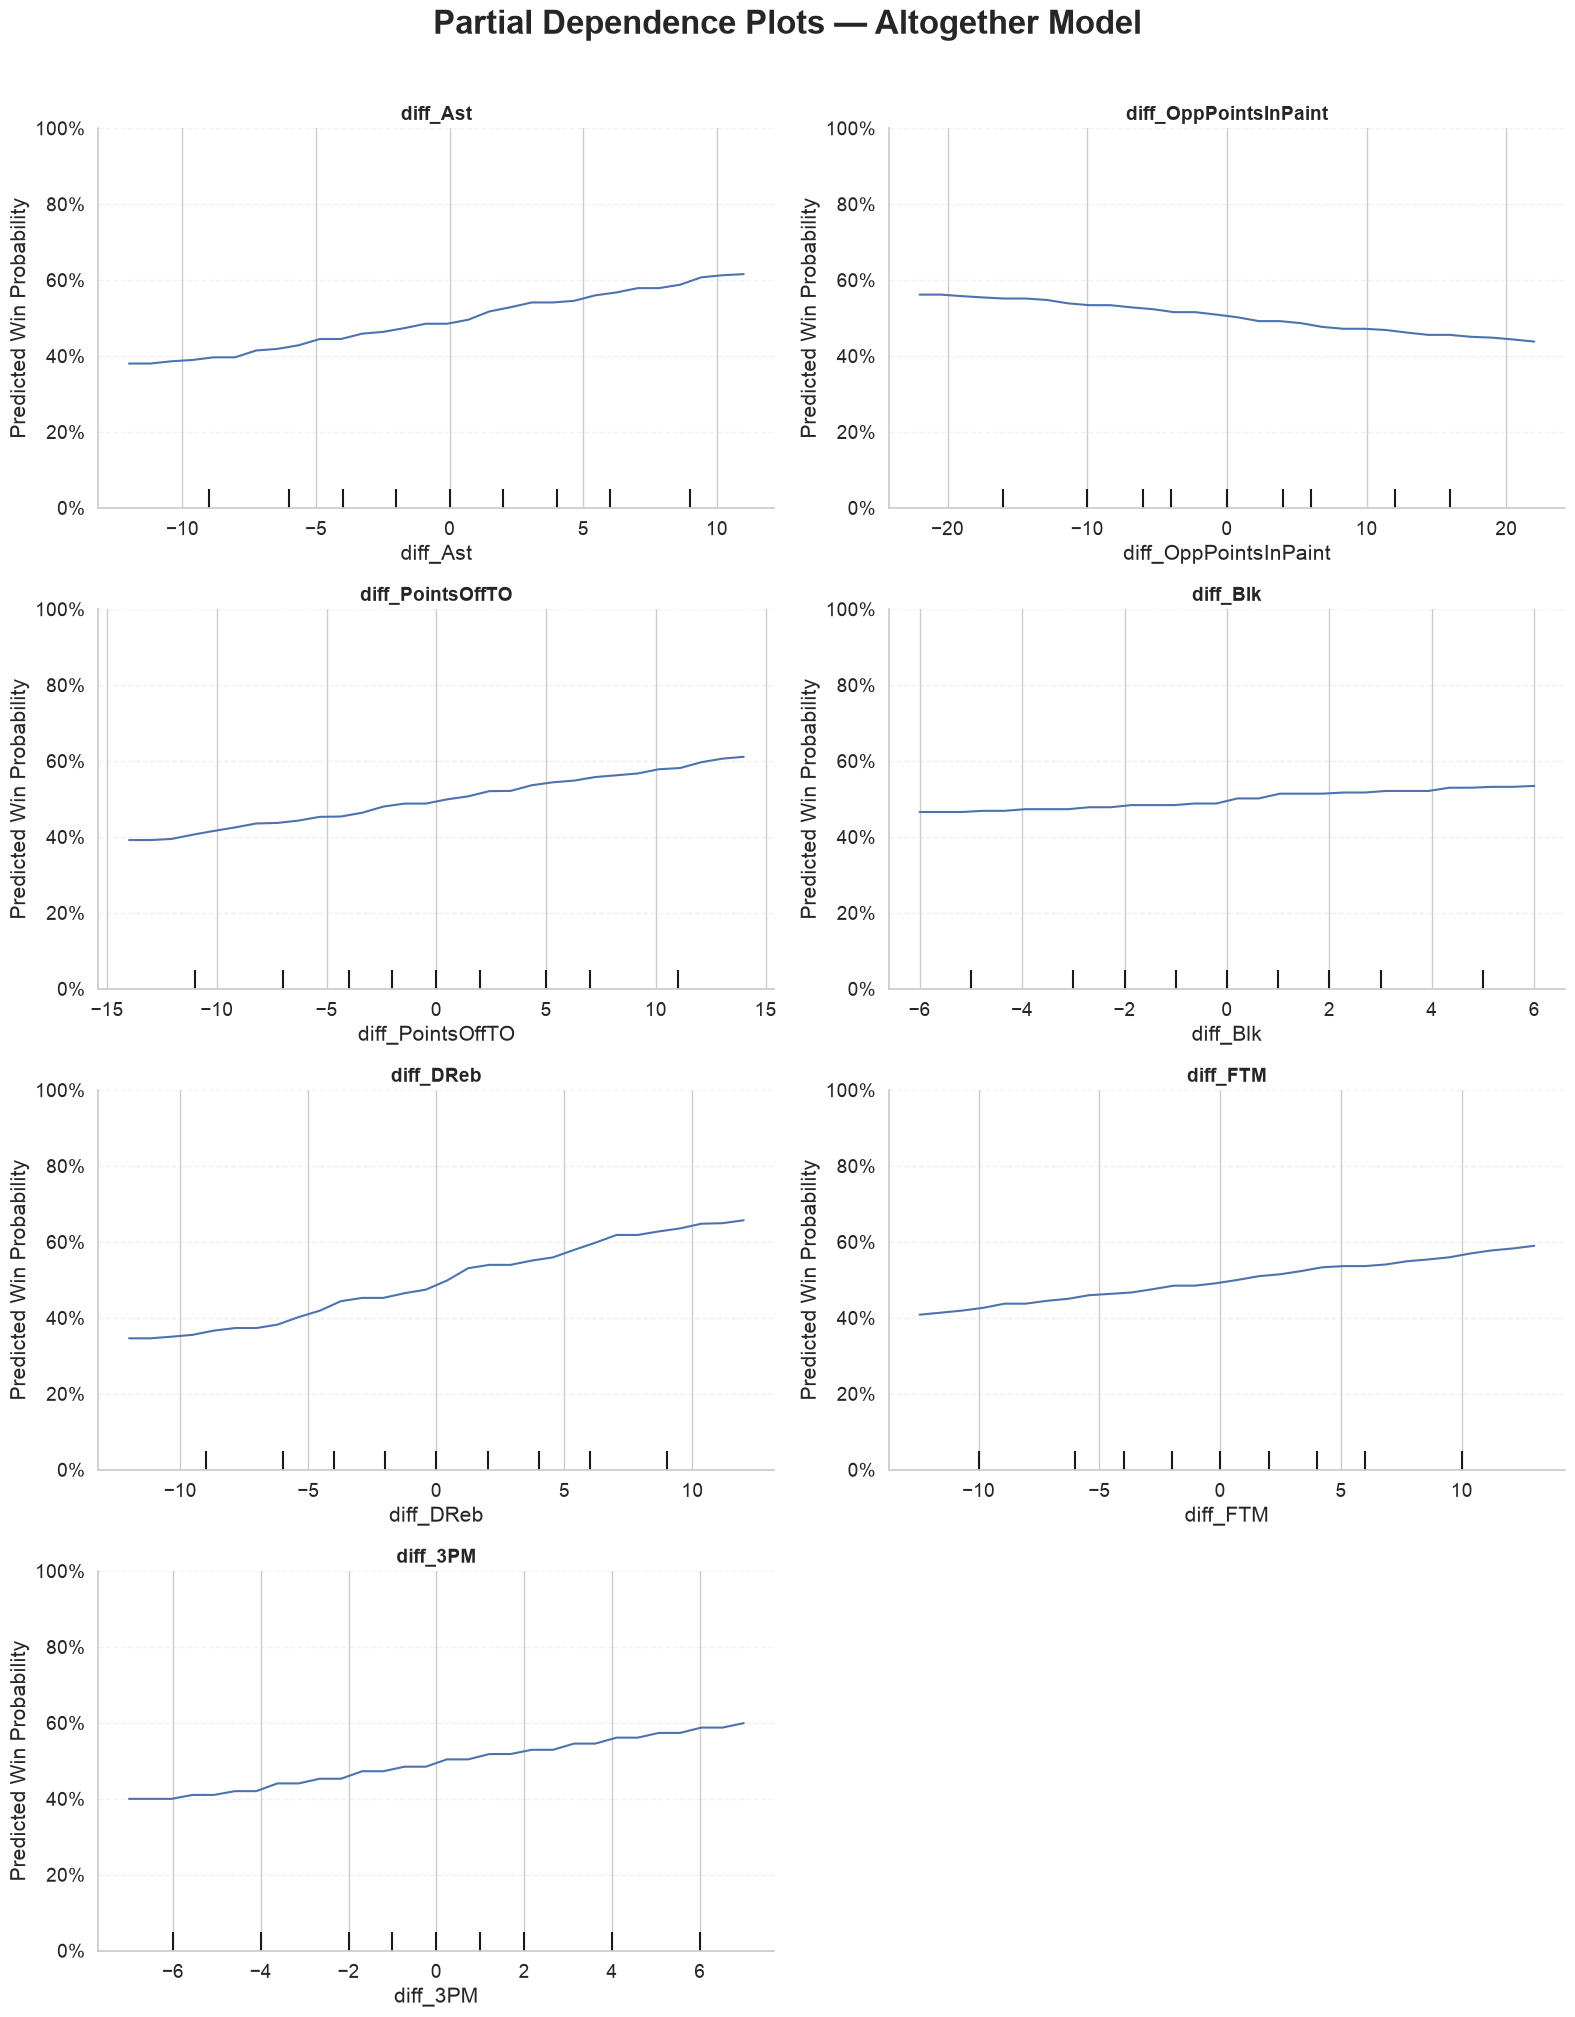

In [31]:
# Extract features
features = list(X_test_Altogether.columns)
n_features = len(features)

# Layout
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 5 * n_rows)
)

axes = np.array(axes).flatten()

# PDP
PartialDependenceDisplay.from_estimator(
    best_model_Altogether,
    X_test_Altogether,
    features,
    ax=axes[:n_features],
    grid_resolution=30
)

# Formatting
for i, feature in enumerate(features):

    axes[i].set_title(feature, fontsize=14, fontweight="bold")
    axes[i].set_ylabel("Predicted Win Probability")
    axes[i].set_ylim(0, 1)
    axes[i].set_yticks(np.arange(0, 1.1, 0.2))
    axes[i].set_yticklabels([f"{int(x * 100)}%" for x in np.arange(0, 1.1, 0.2)])
    axes[i].grid(axis="y", linestyle="--", alpha=0.25)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

# Hide unused axes
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "Partial Dependence Plots — Altogether Model",
    fontsize=24,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()


#### Plotting Data Material Validity

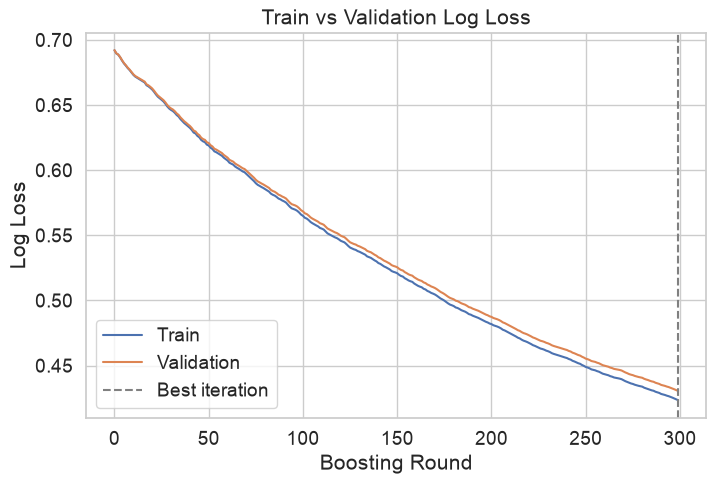

In [32]:
results = best_model_Altogether.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(epochs)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(x_axis, results['validation_0']['logloss'], label='Train')
ax.plot(x_axis, results['validation_1']['logloss'], label='Validation')
ax.axvline(best_model_Altogether.best_iteration, color='gray', linestyle='--', label='Best iteration')
ax.legend()
plt.ylabel('Log Loss')
plt.xlabel('Boosting Round')
plt.title('Train vs Validation Log Loss')
plt.show()

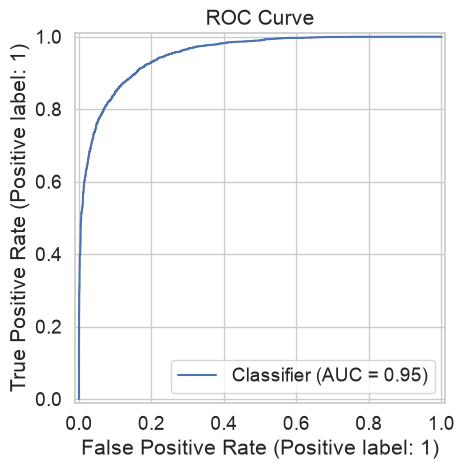

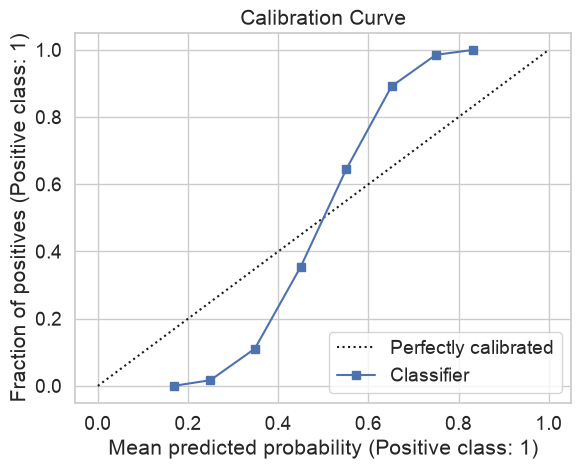

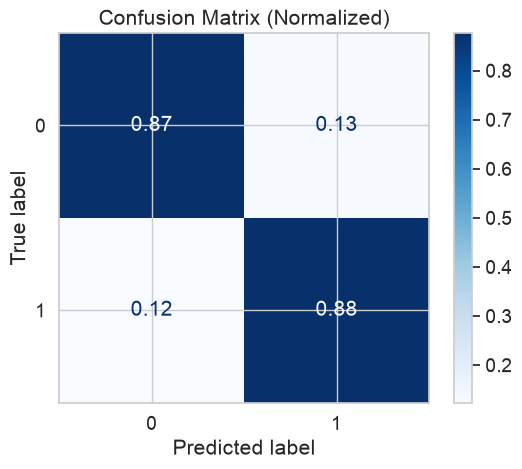

In [33]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(Y_test_Altogether, Y_prob_Altogether)
plt.title('ROC Curve')
plt.show()

from sklearn.calibration import CalibrationDisplay
CalibrationDisplay.from_predictions(Y_test_Altogether, Y_prob_Altogether, n_bins=10)
plt.title('Calibration Curve')
plt.show()

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(Y_test_Altogether, Y_hat_Altogether, normalize='true', cmap='Blues')
plt.title('Confusion Matrix (Normalized)')
plt.show()

# DF_Playoffs

#### Testing on playoff data

In [34]:
df_Playoffs_Altogether = df_Playoffs[col_Altogether].copy()

X_test_Playoffs_Altogether, Y_test_Playoffs_Altogether = df_Playoffs_Altogether.drop(columns = 'Win'), df_Playoffs_Altogether['Win']

Y_hat_Playoffs_Altogether = best_model_Altogether.predict(X_test_Playoffs_Altogether)
Y_prob_Playoffs_Altogether = best_model_Altogether.predict_proba(X_test_Playoffs_Altogether)[:, 1]

#### Plotting Accuracies, etc.



AUC:         0.9492
Log Loss:    0.4315
Accuracy:    0.8721
Brier:       0.1298


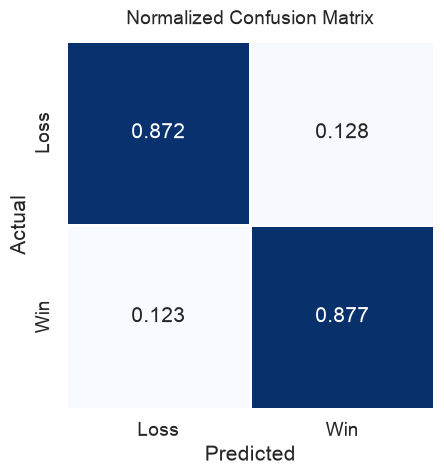

In [35]:
print("\n")
print("AUC:        ", round(roc_auc_score(Y_test_Playoffs_Altogether, Y_prob_Playoffs_Altogether), 4))
print("Log Loss:   ", round(log_loss(Y_test_Playoffs_Altogether, Y_prob_Playoffs_Altogether), 4))
print("Accuracy:   ", round(accuracy_score(Y_test_Playoffs_Altogether, Y_hat_Playoffs_Altogether), 4))
print("Brier:      ", round(brier_score_loss(Y_test_Playoffs_Altogether, Y_prob_Playoffs_Altogether), 4))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    Y_test_Altogether,
    Y_hat_Altogether,
    normalize='true'
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    cbar=False,
    square=True,
    linewidths=1,
    linecolor='white',
    xticklabels=['Loss', 'Win'],
    yticklabels=['Loss', 'Win']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix', fontsize=14, pad=12)

plt.tight_layout()
plt.show()

# Future Use Exporting

In [36]:
# Save to JSON 
best_model_Altogether.save_model("best_model_Altogether.json")